### Libraries

In [2]:
library(tuneR)
library(signal)
library(seewave)
library(wavelets)
library(lintr)
library(ggplot2)
library(plotly)
library(Rtsne)
library(pracma)
library(fields)
library(soundgen)
library(viridisLite)
library(e1071)
library(caret)
library(dplyr)
library(class)
library(umap)
library(randomForest)


In [40]:
df <- readRDS("./data/Propagation_experiments/df_pca.rds")
summary(df)
print(dim(df))


      PC1               PC2                PC3               PC4          
 Min.   :-361.50   Min.   :-99.3496   Min.   :-58.278   Min.   :-59.7546  
 1st Qu.:-176.72   1st Qu.:-28.5394   1st Qu.:-19.732   1st Qu.: -6.6299  
 Median : -40.15   Median : -0.8788   Median :  3.043   Median : -0.1527  
 Mean   :   0.00   Mean   :  0.0000   Mean   :  0.000   Mean   :  0.0000  
 3rd Qu.: 174.16   3rd Qu.: 26.5544   3rd Qu.: 19.422   3rd Qu.:  7.4839  
 Max.   : 433.26   Max.   :108.7014   Max.   : 65.182   Max.   : 44.2455  
      PC5               PC6               PC7                PC8          
 Min.   :-56.632   Min.   :-68.345   Min.   :-29.1952   Min.   :-35.1108  
 1st Qu.: -7.021   1st Qu.: -7.761   1st Qu.: -8.8198   1st Qu.: -5.0442  
 Median :  2.603   Median :  1.388   Median : -0.5631   Median : -0.2328  
 Mean   :  0.000   Mean   :  0.000   Mean   :  0.0000   Mean   :  0.0000  
 3rd Qu.: 10.303   3rd Qu.:  8.760   3rd Qu.:  7.8991   3rd Qu.:  4.7275  
 Max.   : 30.796   Max.  

[1] 800 802


## Plotting functions

In [98]:
plot_df_pca_2D <- function(df, colorType = "Individual", sizeDiff = TRUE, distance = TRUE){
    if (sizeDiff){
        size_map <- setNames(c(0.2, 0.4, 0.6, 0.8, 1), c("0","12-5", "25", "50", "100"))
    }else{
        size_map <- setNames(c(1,1,1,1,1), c("0", "12-5", "25", "50", "100"))
    }
    par(mar = c(5, 4, 4, 8), xpd = TRUE) 

    if (colorType == "Individual"){
        df$Individual <- as.factor(df$Individual)
        unique_individuals <- levels(df$Individual) 
        individual_colors <- setNames(rainbow(length(unique_individuals)), unique_individuals)

        type_pch_map <- setNames(c(19,17), c("Vocalization", "Noise"))
        
        plot(x = df$PC1, 
             y = df$PC2, 
             col = individual_colors[df$Individual],
             cex = size_map[df$Distance],  
             pch = type_pch_map[df$Type],  
             xlab = "PC1", 
             ylab = "PC2",
             main = "2D PCA",
             xaxs = "r", 
             yaxs = "r"   
        )

        legend("topright", legend = unique_individuals, col = individual_colors, pch = 19, title = "Individuals", xpd = TRUE, inset = c(-0.3, 0))
        if (distance) legend("bottomright", legend = names(size_map), pch = 19, pt.cex = size_map, col = "black", title = "Distance", xpd = TRUE, inset = c(-0.2, 0))

    }
    if (colorType == "Type"){
        df$Type <- as.factor(df$Type)

        type_colors <- setNames(c("blue", "red"), levels(df$Type))  

        plot(x = df$PC1, 
             y = df$PC2, 
             col = type_colors[df$Type],  
             cex = size_map[df$Distance],  
             pch = 19,
             xlab = "PC1", 
             ylab = "PC2",
             main = "2D PCA",
             xaxs = "r",
             yaxs = "r" 
        )

        legend("topright", legend = levels(df$Type), col = type_colors, pch = 19, title = "Type", xpd = TRUE, inset = c(-0.3, 0))
        if (distance) legend("bottomright", legend = names(size_map), pch = 19, pt.cex = size_map, col = "black", title = "Distance", xpd = TRUE, inset = c(-0.2, 0))

    }
    if (colorType == "Distance"){
        df$Distance <- as.factor(df$Distance)
        unique_distances <- levels(df$Distance)
        type_colors <- setNames(rainbow(length(unique_distances)), unique_distances) 

        plot(x = df$PC1, 
             y = df$PC2, 
             col = type_colors[df$Distance],  
             cex = 1,  
             pch = 19,
             xlab = "PC1", 
             ylab = "PC2",
             main = "2D PCA",
             xaxs = "r",
             yaxs = "r" 
        )

        legend("topright", legend = levels(df$Distance), col = type_colors, pch = 19, title = "Distance", xpd = TRUE, inset = c(-0.3, 0))
        if (distance) legend("bottomright", legend = names(size_map), pch = 19, pt.cex = size_map, col = "black", title = "Distance", xpd = TRUE, inset = c(-0.2, 0))


    }
}


In [99]:
plot_df_umap_2D <- function(df, colorType = "Individual", sizeDiff = TRUE, distance = TRUE) {
    if (sizeDiff) {
        size_map <- setNames(c(0.2, 0.4, 0.6, 0.8, 1), c("0", "12-5", "25", "50", "100"))
    } else {
        size_map <- setNames(c(1, 1, 1, 1, 1), c("0", "12-5", "25", "50", "100"))
    }
    
    # Select only numeric columns for UMAP
    numeric_cols <- sapply(df, is.numeric)
    df_numeric <- df[, numeric_cols]
    
    # Perform UMAP
    umap_result <- umap(df_numeric)
    df$UMAP1 <- umap_result$layout[, 1]
    df$UMAP2 <- umap_result$layout[, 2]
    
    if (colorType == "Individual") {
        df$Individual <- as.factor(df$Individual)
        unique_individuals <- levels(df$Individual)
        individual_colors <- setNames(rainbow(length(unique_individuals)), unique_individuals)
        
        ggplot(df, aes(x = UMAP1, y = UMAP2, color = Individual, size = Distance)) +
            geom_point(alpha = 0.6) +
            scale_color_manual(values = individual_colors) +
            scale_size_manual(values = size_map) +
            labs(title = "UMAP 2D", x = "UMAP1", y = "UMAP2") +
            theme_minimal() +
            guides(size = guide_legend(title = "Distance"), color = guide_legend(title = "Individuals"))
    } else if (colorType == "Type") {
        df$Type <- as.factor(df$Type)
        type_colors <- setNames(c("blue", "red"), levels(df$Type))
        
        ggplot(df, aes(x = UMAP1, y = UMAP2, color = Type, size = Distance)) +
            geom_point(alpha = 0.6) +
            scale_color_manual(values = type_colors) +
            scale_size_manual(values = size_map) +
            labs(title = "UMAP 2D", x = "UMAP1", y = "UMAP2") +
            theme_minimal() +
            guides(size = guide_legend(title = "Distance"), color = guide_legend(title = "Type"))
    } else {
        df$Distance <- as.factor(df$Distance)
        unique_distances <- levels(df$Distance)
        distance_colors <- setNames(rainbow(length(unique_distances)), unique_distances)
        
        ggplot(df, aes(x = UMAP1, y = UMAP2, color = Distance, size = Distance)) +
            geom_point(alpha = 0.6) +
            scale_color_manual(values = distance_colors) +
            scale_size_manual(values = size_map) +
            labs(title = "UMAP 2D", x = "UMAP1", y = "UMAP2") +
            theme_minimal() +
            guides(size = guide_legend(title = "Distance"), color = guide_legend(title = "Distance"))
    }
}



In [100]:
plot_cm <- function(cm, cm_title="Confusion matrix", cm_stats = TRUE){
  cm_table <- as.data.frame(cm$table)
  colnames(cm_table) <- c("Predicted", "Actual", "Freq")
  
  if (cm_stats == TRUE){
    stats <- cm$overall
    cat("\nOverall Statistics:\n")
    cat("Accuracy: ", stats["Accuracy"], "\n")
    cat("95% CI: (", stats["AccuracyLower"], ",", stats["AccuracyUpper"], ")\n")
    cat("No Information Rate: ", stats["AccuracyNull"], "\n")
    cat("P-Value [Acc > NIR]: ", stats["AccuracyPValue"], "\n")
    cat("Kappa: ", stats["Kappa"], "\n")

    class_metrics <- as.data.frame(cm$byClass)

    cat("\nStatistics by Class:\n")
    print(round(class_metrics, 4))
  }

  ggplot(data = cm_table, aes(x = Actual, y = Predicted, fill = Freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = Freq), color = "black", size = 5) +
    scale_fill_gradient(low = "lightblue", high = "red") +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank()
    ) +
    labs(
      title = cm_title,
      x = "Actual Labels",
      y = "Predicted Labels",
      fill = "Count"
    )
  
}



## Plotting in 2D and 3D

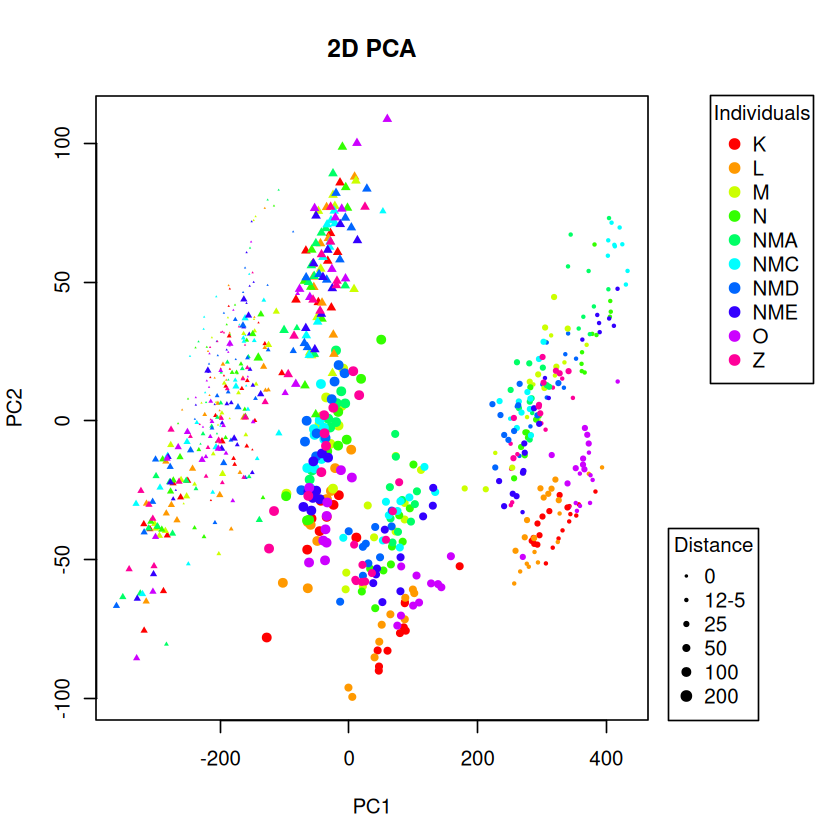

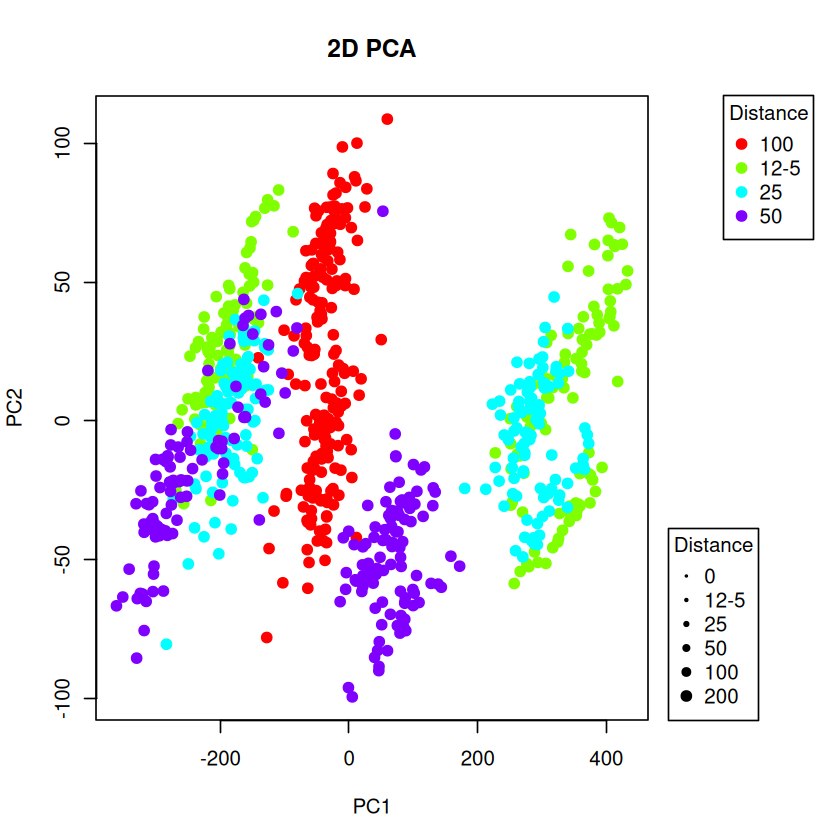

In [7]:
plot_df_pca_2D(df, colorType = "Individual")


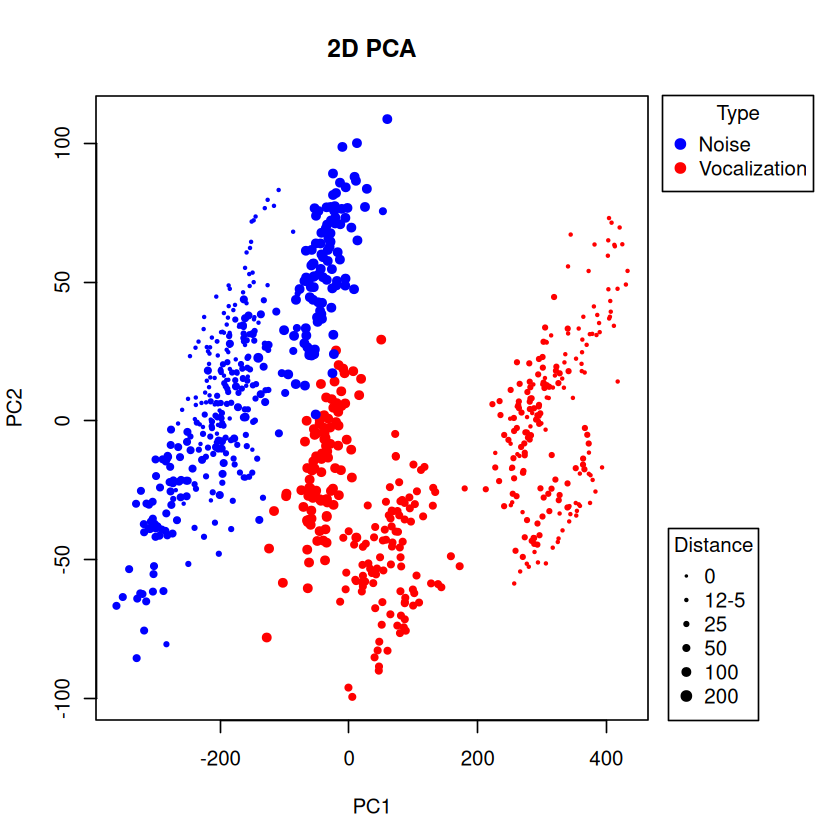

In [8]:
plot_df_pca_2D(df, colorType = "Type")


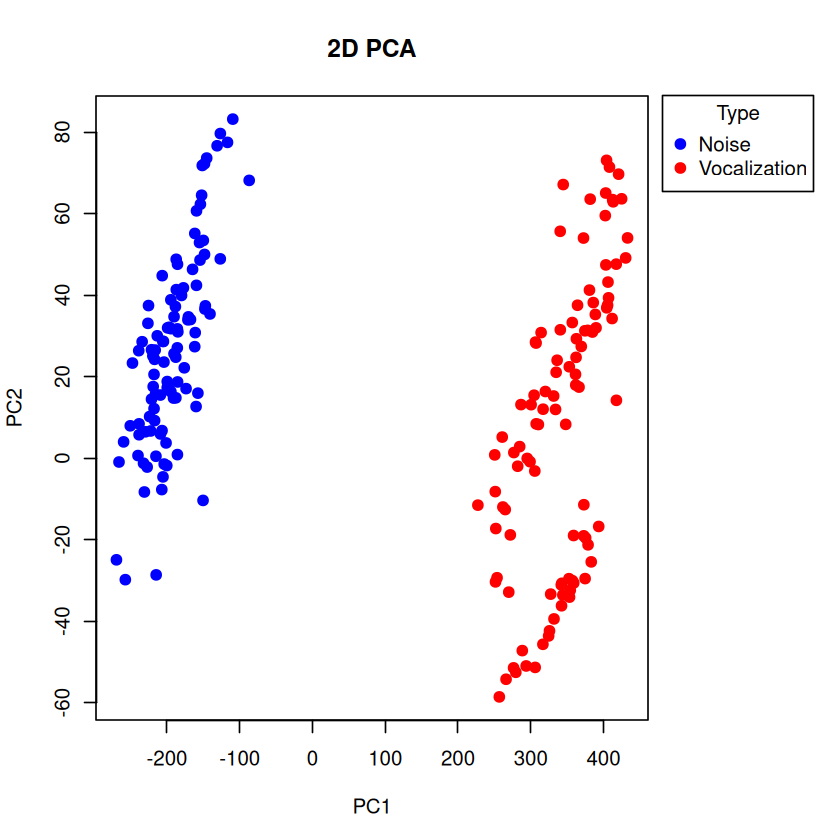

In [12]:
df_filt <- df %>% filter(Distance == "12-5")
plot_df_pca_2D(df_filt, colorType = "Type", sizeDiff = FALSE, distance = FALSE)


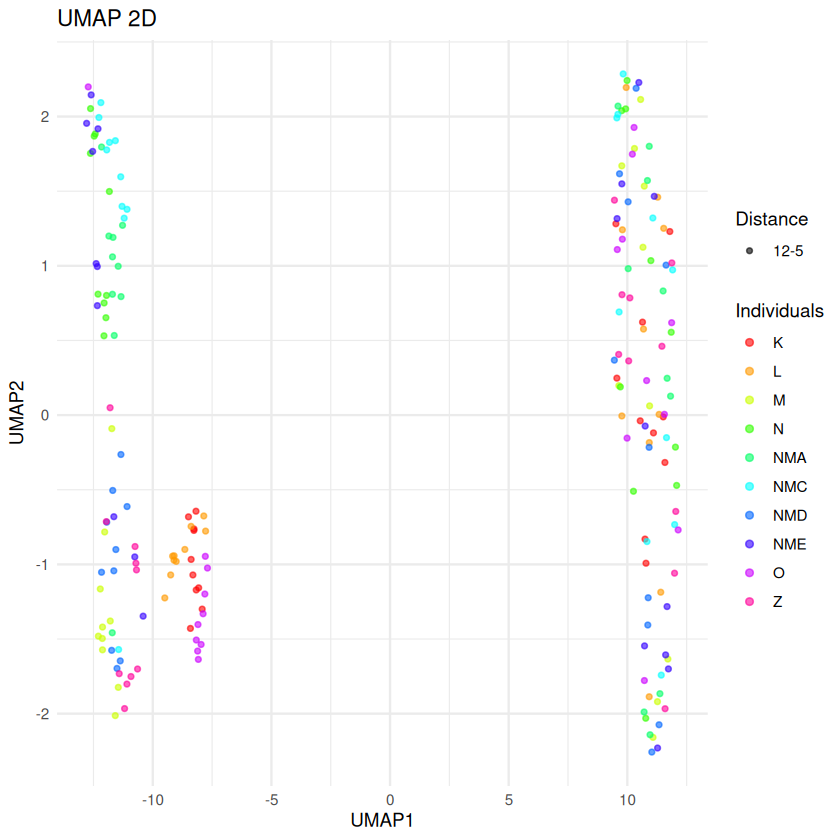

In [10]:
df_filt <- df %>% filter(Distance == "12-5")
plot_df_umap_2D(df_filt, colorType = "Individual", sizeDiff = FALSE, distance = TRUE)


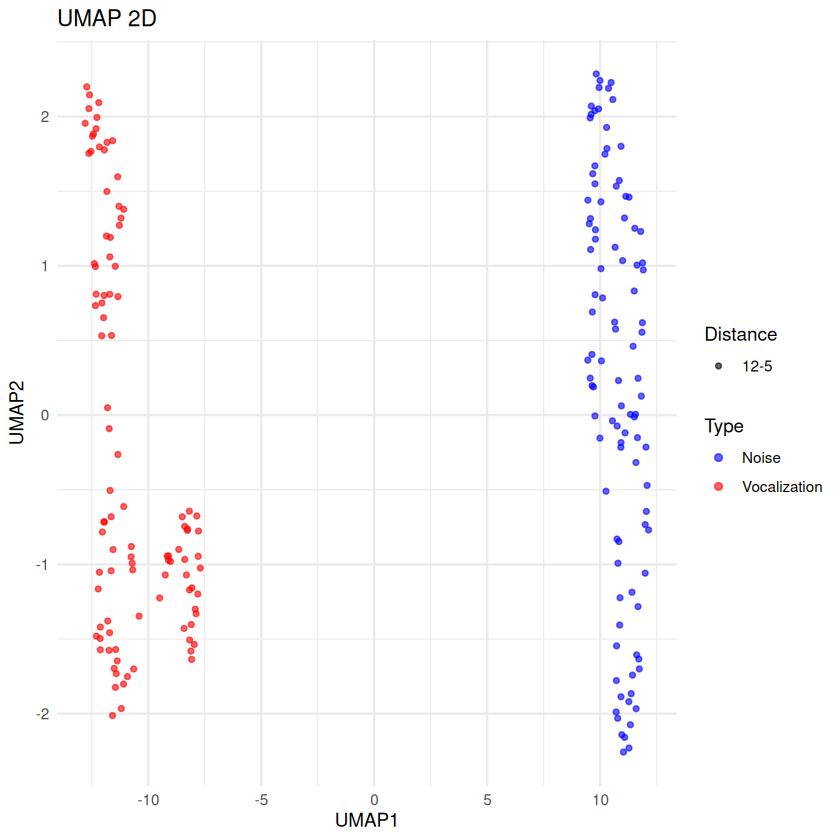

In [13]:
df_filt <- df %>% filter(Distance == "12-5")
plot_df_umap_2D(df_filt, colorType = "Type", sizeDiff = FALSE, distance = TRUE)


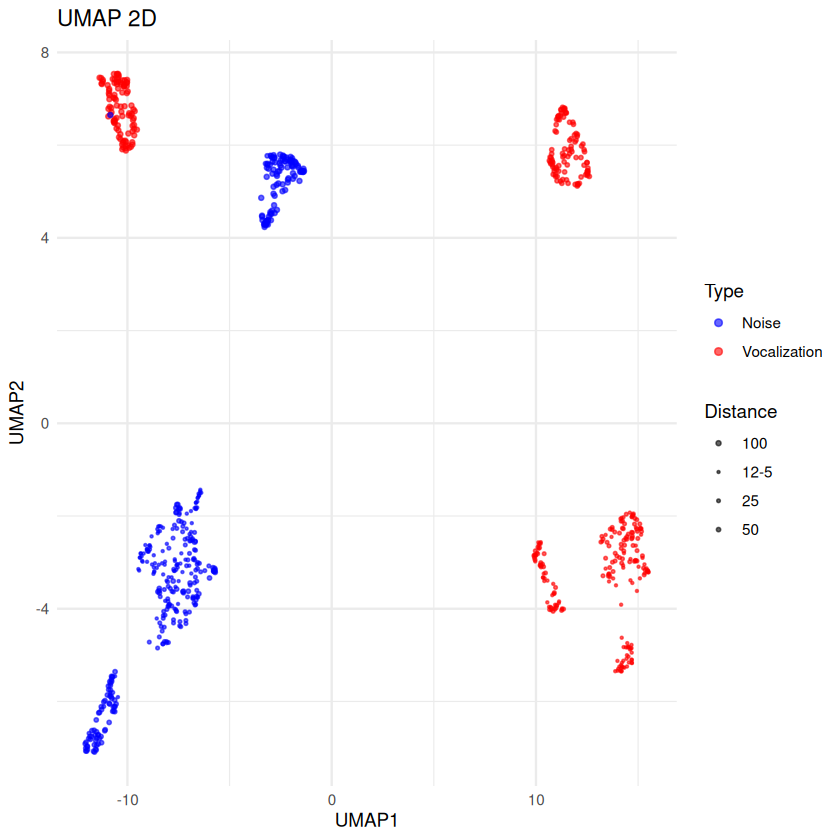

In [14]:
plot_df_umap_2D(df, colorType = "Type", sizeDiff = TRUE, distance = TRUE)


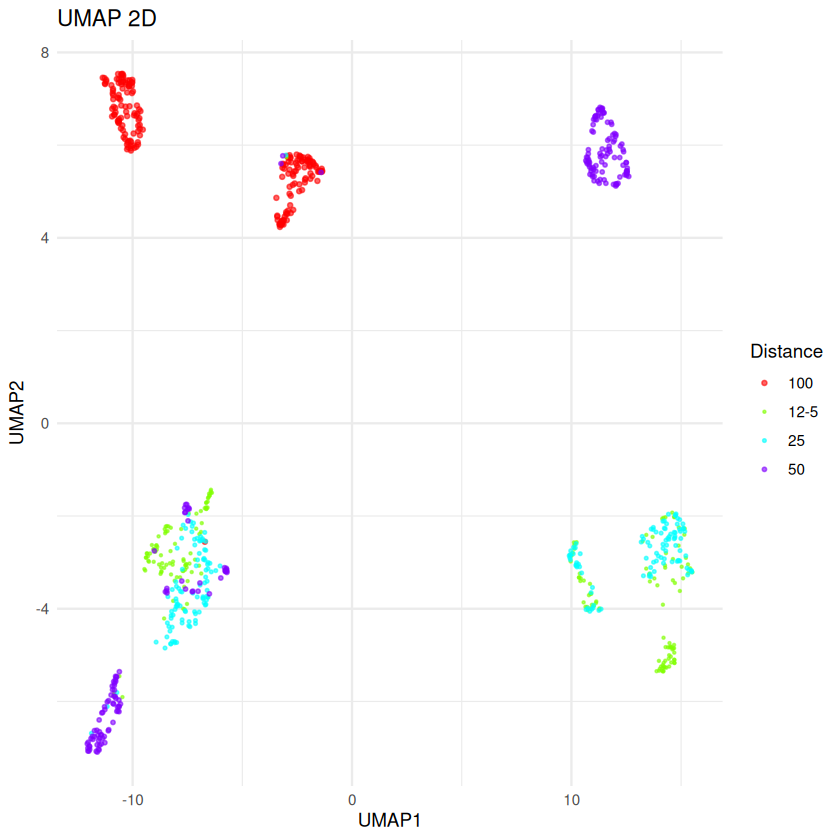

In [15]:

plot_df_umap_2D(df, colorType = "dza", sizeDiff = TRUE, distance = TRUE)


In [22]:
pca_data <- data.frame(PC1 = df$PC1, PC2 = df$PC2, PC3 = df$PC3, Label = df$Individual, Distance = df$Distance, Type = df$Type)

pca_data$marker_size <- ifelse(
  pca_data$Distance == "12-5", 3,
  ifelse(pca_data$Distance == "25", 5,
  ifelse(pca_data$Distance == "50", 7,
  ifelse(pca_data$Distance == "100", 9,1))) 
)

pca_data <- pca_data[order(pca_data$Label), ] 

plot_ly(pca_data,
        type = "scatter3d",
        mode = "markers",
        x = ~PC1,
        y = ~PC2,
        z = ~PC3,
        color = ~Type, 
        colors = c("Vocalization" = "red", "Noise" = "blue"), 
        text = ~paste("Ind: ", Label, "<br>Distance: ", Distance, "<br>Type:", Type),
        hoverinfo = "text",
        marker = list(size = pca_data$marker_size, opacity = 0.4)) %>%
  layout(title = "PCA Projection",
         scene = list(xaxis = list(title = "PC1"),
                      yaxis = list(title = "PC2"),
                      zaxis = list(title = "PC3")))


HTML widgets cannot be represented in plain text (need html)

### Classifying Signals VS Noise

In [41]:
set.seed(42)

df <- df[sample(nrow(df)), ] 

df$Type <- factor(df$Type, levels = c("Vocalization", "Noise"))

df_filt <- df %>% filter(Distance == "100")

X <- df_filt[ , 1:(ncol(df)-797)]
y <- df_filt$Type

train_index <- createDataPartition(df_filt$Type, p = 0.5, list = FALSE)

X_train <- X[train_index, ]
y_train <- y[train_index]

X_test <- X[-train_index, ]
y_test <- y[-train_index]

k <- 3
y_pred <- knn(train = X_train, test = X_test, cl = y_train, k = k)

confusion_matrix <- confusionMatrix(y_pred, y_test)
plot_cm(confusion_matrix)

misclassified_indices <- which(y_pred != y_test)

misclassified_info <- data.frame(
  True_Label = y_test[misclassified_indices],
  Predicted_Label = y_pred[misclassified_indices],
  Distance = df_filt$Distance[-train_index][misclassified_indices]  
)

print("Misclassified Examples (True vs Predicted Labels, Distance):")
print(misclassified_info)


ERROR: Error in as.data.frame.default(cm): cannot coerce class ‘"confusionMatrix"’ to a data.frame


[1] "Misclassified Examples (True vs Predicted Labels, Distance):"
    True_Label Predicted_Label Distance
1 Vocalization           Noise      100
2        Noise    Vocalization      100
3 Vocalization           Noise      100
4 Vocalization           Noise      100
5        Noise    Vocalization      100
6        Noise    Vocalization      100


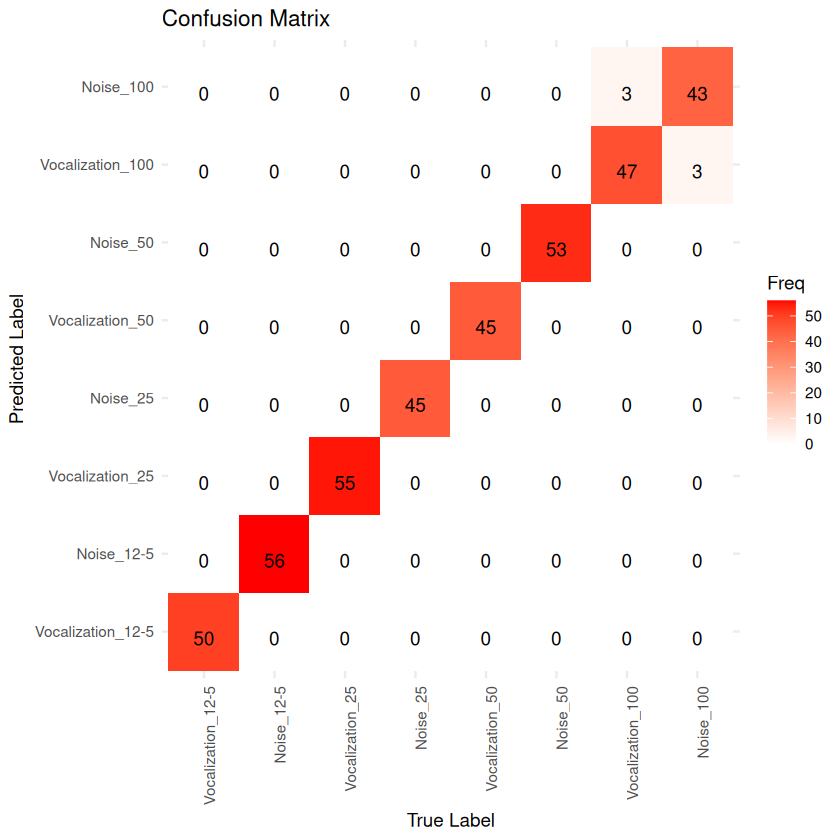

In [88]:
set.seed(42)

df <- df[sample(nrow(df)), ] 

df$Type <- factor(df$Type, levels = c("Vocalization", "Noise"))

# Filter for all distances
df_filt <- df %>% filter(Distance %in% c("12-5", "25", "50", "100", "200"))

X <- df_filt[ , 1:(ncol(df)-797)]
y <- df_filt$Type

train_index <- createDataPartition(df_filt$Type, p = 0.5, list = FALSE)

X_train <- X[train_index, ]
y_train <- y[train_index]

X_test <- X[-train_index, ]
y_test <- y[-train_index]

rf_model <- randomForest(x = X_train, y = y_train, ntree = 500, mtry = 3, importance = TRUE)

y_pred <- predict(rf_model, X_test)

results <- data.frame(
  True_Label = y_test,
  Predicted_Label = y_pred,
  Distance = df_filt$Distance[-train_index]
)

results$Combined_True <- factor(paste(results$True_Label, results$Distance, sep = "_"), 
                                levels = c("Vocalization_12-5", "Noise_12-5", 
                                           "Vocalization_25", "Noise_25", 
                                           "Vocalization_50", "Noise_50", 
                                           "Vocalization_100", "Noise_100"))
results$Combined_Pred <- factor(paste(results$Predicted_Label, results$Distance, sep = "_"), 
                                levels = c("Vocalization_12-5", "Noise_12-5", 
                                           "Vocalization_25", "Noise_25", 
                                           "Vocalization_50", "Noise_50", 
                                           "Vocalization_100", "Noise_100"))

confusion_matrix <- table(results$Combined_True, results$Combined_Pred)

plot_cm <- function(cm) {
  cm_table <- as.data.frame(cm)
  ggplot(cm_table, aes(x = Var1, y = Var2, fill = Freq)) +
    geom_tile() +
    geom_text(aes(label = Freq), vjust = 1) +
    scale_fill_gradient(low = "white", high = "red") +
    labs(title = "Confusion Matrix", x = "True Label", y = "Predicted Label") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1))
}

plot_cm(confusion_matrix)

misclassified_indices <- which(results$True_Label != results$Predicted_Label)

misclassified_info <- data.frame(
  True_Label = results$True_Label[misclassified_indices],
  Predicted_Label = results$Predicted_Label[misclassified_indices],
  Distance = results$Distance[misclassified_indices]  
)

print("Misclassified Examples (True vs Predicted Labels, Distance):")
print(misclassified_info)


## Training and Testing on SAME Distance

In [46]:
cross_validation <- function(X_train, X_test, y_train, y_test, model, n_folds = 5){
    # Defining the hyperparameters for each of the algorithms 
    grid_svm = expand.grid(C = c(1,2,3,5), sigma = c(0.01, 0.05, 0.1)) #svmRadial

    grid_svm_poly = expand.grid(C = c(1,10,100), degree = c(2,4,8,16), scale = c(1,10)) #svmPoly

    grid_rf = expand.grid(mtry = c(1,2,3,5,6,7,8,9,10)) #rf

    grid_nn <- expand.grid( #nnet
        size = c(10,20),     
        decay = c(2)
    )

    grid_knn <- expand.grid(k = c(1,3,5,7,9,11,13))

    if (model == "rf"){
        grid = grid_rf
    }
    if (model == "svmRadial"){
        grid = grid_svm
    }
    if (model == "svmPoly"){
        grid = grid_svm_poly
    }
    if (model == "nnet"){
        grid = grid_nn
    }
    if (model == "knn") grid = grid_knn

    model_train <- train(
        x = X_train,
        y = y_train,
        method = model,  
        tuneGrid = grid,
        preProcess = c("center", "scale"),  
        trControl = trainControl(
            method = "repeatedcv", 
            number = n_folds,    
            classProbs = TRUE, 
            savePredictions = TRUE,
            sampling = "up" 
        )
    )

    return (model_train)
}


In [47]:
bootstrap_evaluation <- function(df, B = 100, PC = 25, model_algo = "rf", shuffleIndividuals = FALSE, plot = TRUE) {
    metrics <- data.frame(Accuracy = numeric(B))
    confusion_matrices <- vector("list", B)  # Store confusion matrices

    for (i in 1:B) {
        # Creating and shuffling the dataset
        df_bootstrap <- data.frame(df) 
        df_bootstrap$Individual <- factor(df_bootstrap$Individual)
        
        df_bootstrap <- df_bootstrap[sample(nrow(df)), ] 
        
        if (shuffleIndividuals) df_bootstrap$Individual <- sample(df_bootstrap$Individual)

        # Creating the train and test sets
        train_size <- runif(1, min = 0.6, max = 0.8)
        train_indices <- createDataPartition(df_bootstrap$Individual, p = train_size, list = FALSE)

        train_data <- df_bootstrap[train_indices, ]
        test_data <- df_bootstrap[-train_indices, ]

        n_PC <- PC

        X_train <- train_data[ , 1:n_PC]
        y_train <- train_data$Individual

        X_test <- test_data[ , 1:n_PC]
        y_test <- test_data$Individual

        # Finding the best model by cross-validation
        model <- cross_validation(X_train, X_test, y_train, y_test, model_algo)

        # Retraining on the whole training data with the best model
        boot_model <- train(
            x = X_train,
            y = y_train,
            method = model_algo,
            tuneGrid = model$bestTune,
            preProcess = c("center", "scale")
        )

        # Calculating accuracy over the test set
        y_pred <- predict(boot_model, newdata = X_test)
        cm <- confusionMatrix(y_pred, y_test)

        # Storing results
        metrics[i, "Accuracy"] <- cm$overall["Accuracy"]
        confusion_matrices[[i]] <- cm
    }

    cat("\nBootstrap Evaluation Results (", B, " iterations):\n")
    print(summary(metrics))

    # Plotting results
    if (plot){
        boxplot(metrics$Accuracy, main = "Bootstrap Accuracy Distribution", col="lightblue")

        plot(1:B, metrics$Accuracy, type = "l", col = "blue", lwd = 2,
            xlab = "Bootstrap Iteration", ylab = "Accuracy",
            main = "Accuracy vs Bootstrap Iterations")
    }

    return(list(metrics = metrics, confusion_matrices = confusion_matrices))
}


### On synthetic data (0 meters)

In [56]:
df_synthetic <- readRDS('./data/Propagation_experiments/df_pca_synthetic.rds')


Training size :  70 
Testing size :  30 


Cross-Validation results : 
  mtry  Accuracy     Kappa AccuracySD   KappaSD
1    1 0.8024176 0.7809035  0.1452471 0.1602422
2    2 0.8320879 0.8132799  0.1444928 0.1591139
3    3 0.8320879 0.8135094  0.1444928 0.1591389
4    5 0.8320879 0.8130748  0.1444928 0.1600090
5    6 0.8187546 0.7988036  0.1717653 0.1891295
6    7 0.8597070 0.8433055  0.1243777 0.1385064
7    8 0.8597070 0.8433055  0.1243777 0.1385064
8    9 0.8597070 0.8433055  0.1243777 0.1385064
9   10 0.8597070 0.8433055  0.1243777 0.1385064

Best Parameters Found:
  mtry
6    7


Warning message:
“model fit failed for Resample08: mtry=7 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”



Overall Statistics:
Accuracy:  0.8 
95% CI: ( 0.6143335 , 0.9228645 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  3.24154e-19 
Kappa:  0.7777778 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K        0.6667      1.0000         1.0000         0.9643    1.0000
Class: L        1.0000      0.9630         0.7500         1.0000    0.7500
Class: M        1.0000      1.0000         1.0000         1.0000    1.0000
Class: N        1.0000      1.0000         1.0000         1.0000    1.0000
Class: NMA      0.6667      1.0000         1.0000         0.9643    1.0000
Class: NMC      0.6667      0.9259         0.5000         0.9615    0.5000
Class: NMD      0.6667      0.9630         0.6667         0.9630    0.6667
Class: NME      1.0000      1.0000         1.0000         1.0000    1.0000
Class: O        0.6667      0.9630         0.6667         0.9630    0.6667
Class: Z        0.6667      0.9630         0.6667         0.9630    0.6667
 

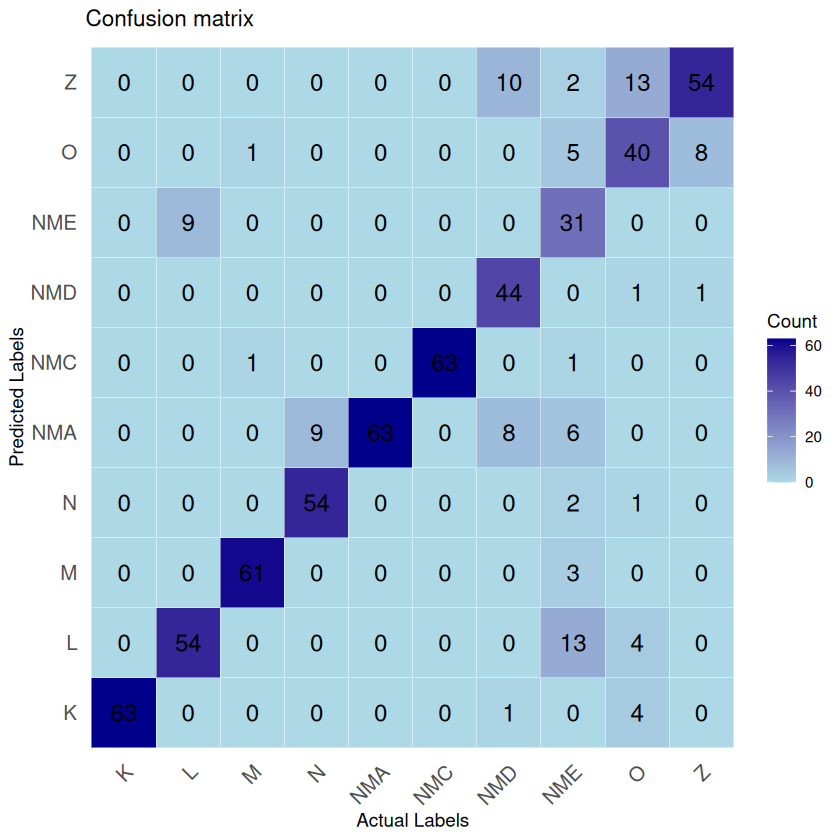

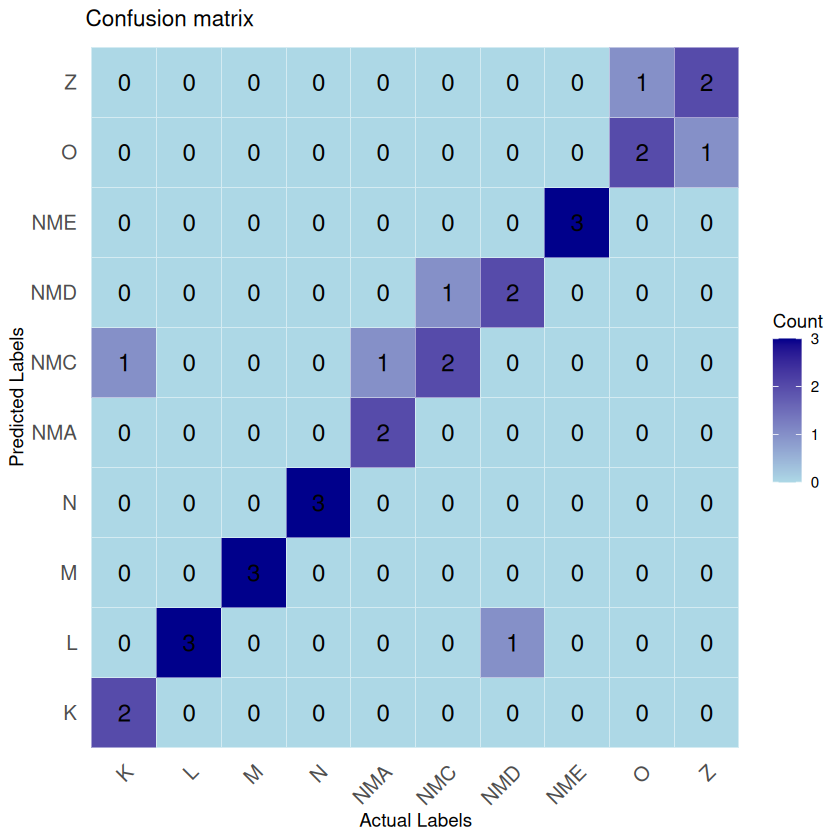

In [210]:
set.seed(42)

df_synthetic <- df_synthetic[sample(nrow(df_synthetic)), ]
df_synthetic$Individual <- factor(df_synthetic$Individual)

train_indices <- createDataPartition(df_synthetic$Individual, p = 0.7, list = FALSE)

train_data <- df_synthetic[train_indices, ]  
test_data <- df_synthetic[-train_indices, ]

cat("Training size : ", nrow(train_data), "\n")
cat("Testing size : ", nrow(test_data), "\n")

n_PC <- 30

# Creating the train and test sets
X_train <- train_data[ , 1:n_PC]
y_train <- train_data$Individual

X_test <- test_data[ , 1:n_PC]
y_test <- test_data$Individual

model_algo = "rf"
model <- cross_validation(X_train, X_test, y_train, y_test, model_algo)
cat("Cross-Validation results : \n")
print(model$results)

cat("\nBest Parameters Found:\n")
print(model$bestTune)

# Display confusion matrix for cross-validation results
cm <- confusionMatrix(model$pred$pred, model$pred$obs)

plot_cm(cm, cm_stats = FALSE)

final_model <- train(
        x = X_train,
        y = y_train,
        method = model_algo,
        tuneGrid = model$bestTune,  
        preProcess = c("center", "scale")
    )

# Display confusion matrix for test set results
y_pred_test <- predict(final_model, newdata = X_test)

cm_test <- confusionMatrix(y_pred_test, y_test)

plot_cm(cm_test, cm_stats = TRUE)


Warning message:
“model fit failed for Resample25: mtry=3 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message:
“model fit failed for Resample08: mtry=6 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message:
“model fit failed for Resample24: mtry=6 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message:
“model fit failed for Resample16: mtry=10 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, in


Bootstrap Evaluation Results ( 1000  iterations):
    Accuracy     
 Min.   :0.6000  
 1st Qu.:0.8000  
 Median :0.8333  
 Mean   :0.8295  
 3rd Qu.:0.8667  
 Max.   :1.0000  


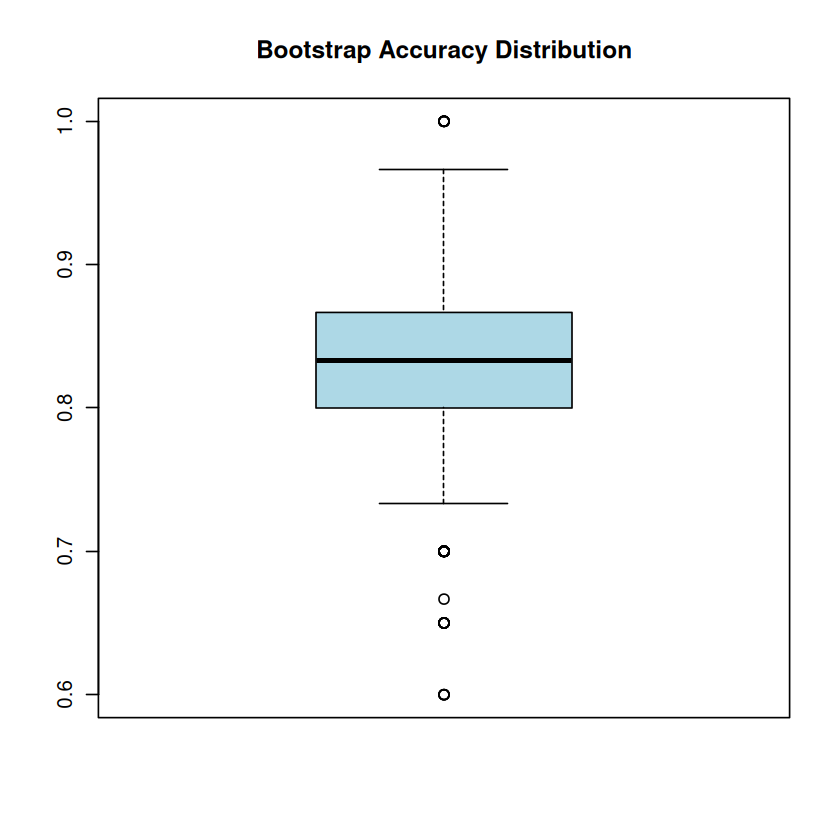


95% Confidence Interval for Accuracy:  0.7 0.95 


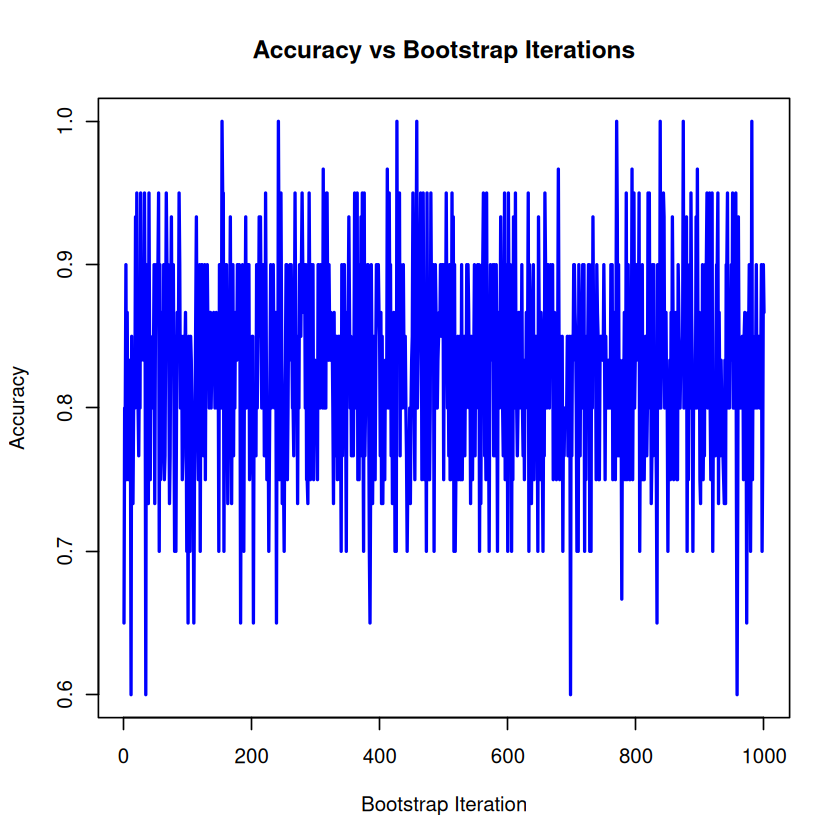

In [379]:
n_B = 1000
bootstrap_results <- bootstrap_evaluation(df_synthetic, B = n_B)

accuracy_ci <- quantile(bootstrap_results$metrics$Accuracy, c(0.025, 0.975))
cat("\n95% Confidence Interval for Accuracy: ", accuracy_ci, "\n")



Overall Statistics:
Accuracy:  0.65 
95% CI: ( 0.4078115 , 0.8460908 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  3.923225e-09 
Kappa:  0.6111111 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K           1.0      1.0000         1.0000         1.0000    1.0000
Class: L           1.0      0.9444         0.6667         1.0000    0.6667
Class: M           1.0      1.0000         1.0000         1.0000    1.0000
Class: N           0.5      1.0000         1.0000         0.9474    1.0000
Class: NMA         0.5      0.8333         0.2500         0.9375    0.2500
Class: NMC         1.0      0.9444         0.6667         1.0000    0.6667
Class: NMD         1.0      1.0000         1.0000         1.0000    1.0000
Class: NME         0.0      1.0000            NaN         0.9000        NA
Class: O           0.0      0.9444         0.0000         0.8947    0.0000
Class: Z           0.5      0.9444         0.5000         0.9444    0.5000

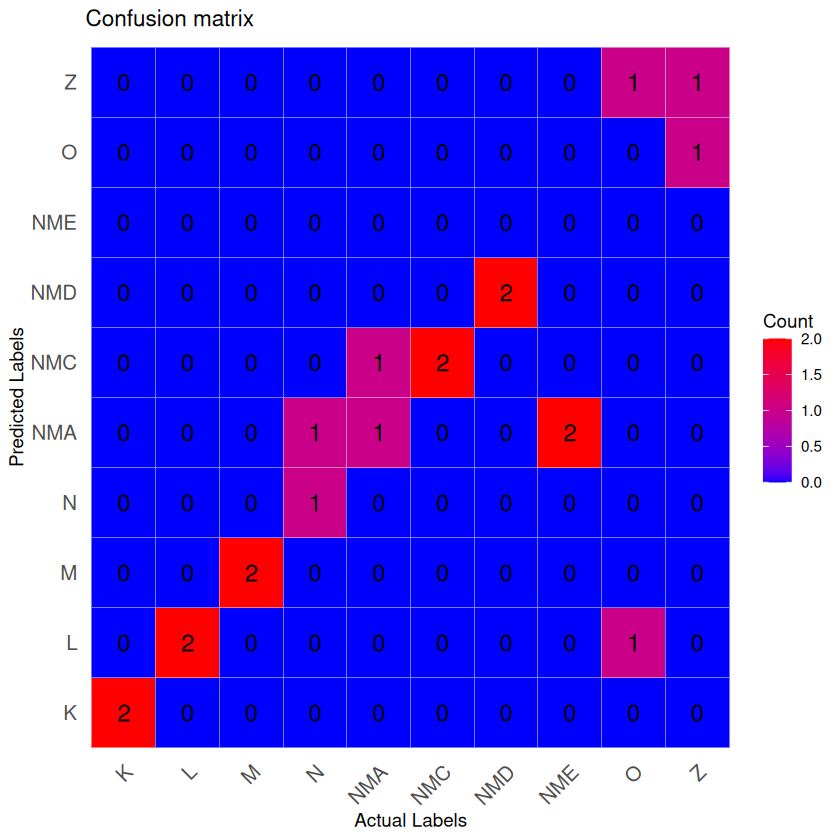

In [386]:
plot_cm(bootstrap_results$confusion_matrices[[1]])


Training size :  70 
Testing size :  30 
Cross-Validation results : 
  mtry   Accuracy       Kappa AccuracySD    KappaSD
1    1 0.04095238 -0.05626454 0.06019620 0.06705390
2    2 0.02761905 -0.07568301 0.03785639 0.04551057
3    3 0.06952381 -0.03174160 0.06913787 0.08196935
4    5 0.05728938 -0.04333574 0.03223089 0.03653011
5    6 0.05619048 -0.04525837 0.05951428 0.07781521
6    7 0.05523810 -0.04422535 0.05640395 0.06696011
7    8 0.02761905 -0.07764362 0.03785639 0.05011836
8    9 0.04190476 -0.05903868 0.03830300 0.04988957
9   10 0.02857143 -0.07625066 0.03912304 0.04746981

Best Parameters Found:
  mtry
3    3

Overall Statistics:
Accuracy:  0.03333333 
95% CI: ( 0.0008435709 , 0.1721695 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  0.9576088 
Kappa:  -0.07407407 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K        0.0000      0.9630         0.0000         0.8966    0.0000
Class: L        0.0000      0.9259     

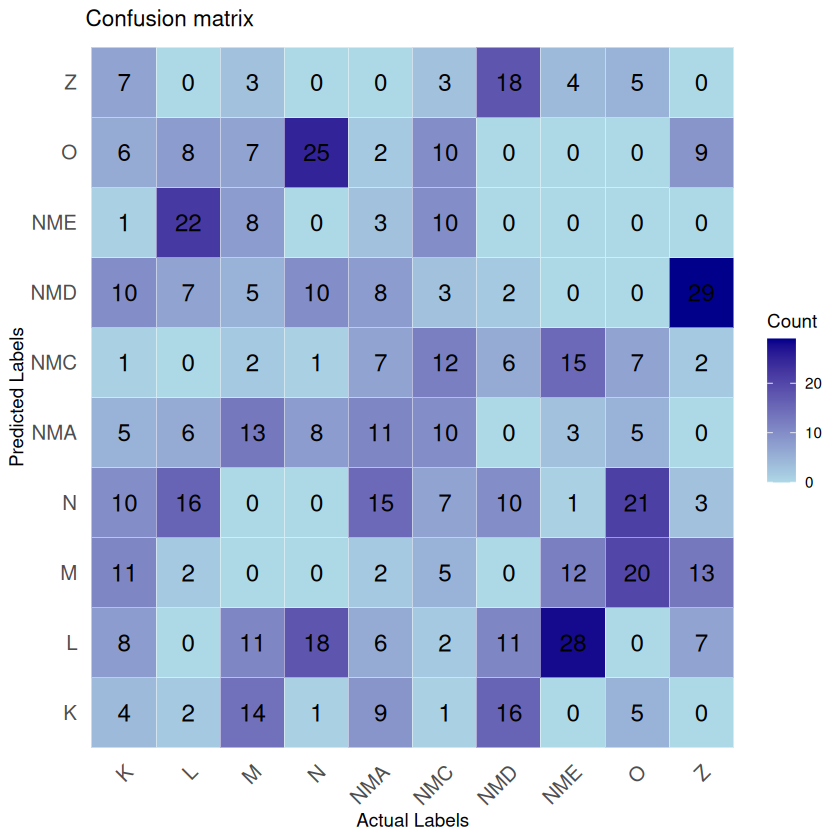

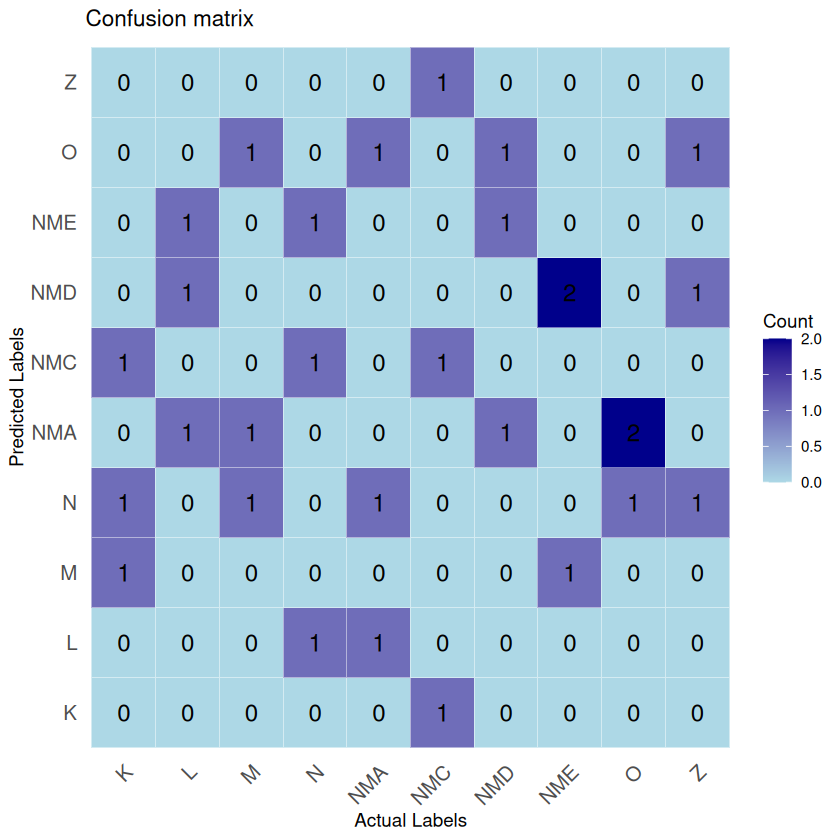

In [ ]:
set.seed(42)  
df_synthetic_shuffled <- copy(df_synthetic)
df_synthetic_shuffled$Individual <- sample(df_synthetic_shuffled$Individual)

train_indices_shuffled <- createDataPartition(df_synthetic_shuffled$Individual, p = 0.7, list = FALSE)

train_data_shuffled <- df_synthetic_shuffled[train_indices_shuffled, ]  
test_data_shuffled <- df_synthetic_shuffled[-train_indices_shuffled, ]

cat("Training size : ", nrow(train_data_shuffled), "\n")
cat("Testing size : ", nrow(test_data_shuffled), "\n")

n_PC_shuffled <- 30

X_train_shuffled <- train_data_shuffled[ , 1:n_PC_shuffled]
y_train_shuffled <- train_data_shuffled$Individual

X_test_shuffled <- test_data_shuffled[ , 1:n_PC_shuffled]
y_test_shuffled <- test_data_shuffled$Individual

model_shuffled <- cross_validation(X_train_shuffled, X_test_shuffled, y_train_shuffled, y_test_shuffled, "rf")
cat("Cross-Validation results : \n")
print(model_shuffled$results)

cat("\nBest Parameters Found:\n")
print(model_shuffled$bestTune)

cm_shuffled <- confusionMatrix(model_shuffled$pred$pred, model_shuffled$pred$obs)
plot_cm(cm_shuffled, cm_stats = FALSE)

final_model_shuffled <- train(
    x = X_train_shuffled,
    y = y_train_shuffled,
    method = "rf",
    tuneGrid = model_shuffled$bestTune,  
    preProcess = c("center", "scale")
)

y_pred_test_shuffled <- predict(final_model_shuffled, newdata = X_test_shuffled)

cm_test_shuffled <- confusionMatrix(y_pred_test_shuffled, y_test_shuffled)

plot_cm(cm_test_shuffled, cm_stats = TRUE)


Warning message:
“model fit failed for Resample05: mtry=7 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message:
“model fit failed for Resample09: mtry=7 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message:
“model fit failed for Resample11: mtry=3 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message:
“model fit failed for Resample09: mtry=7 Error in randomForest.default(x, y, mtry = param$mtry, ...) : 
  Can't have empty classes in y.
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, inf


Bootstrap Evaluation Results ( 1000  iterations):
    Accuracy     
 Min.   :0.0000  
 1st Qu.:0.0500  
 Median :0.1000  
 Mean   :0.1033  
 3rd Qu.:0.1333  
 Max.   :0.3500  


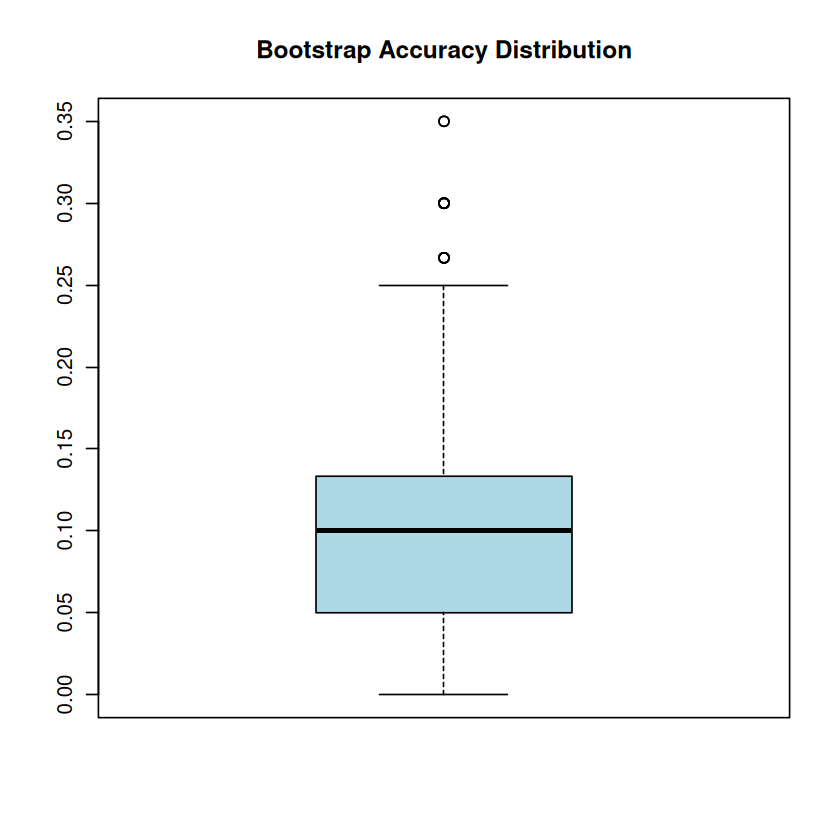


95% Confidence Interval for Accuracy with Shuffled Labels:  0 0.25 


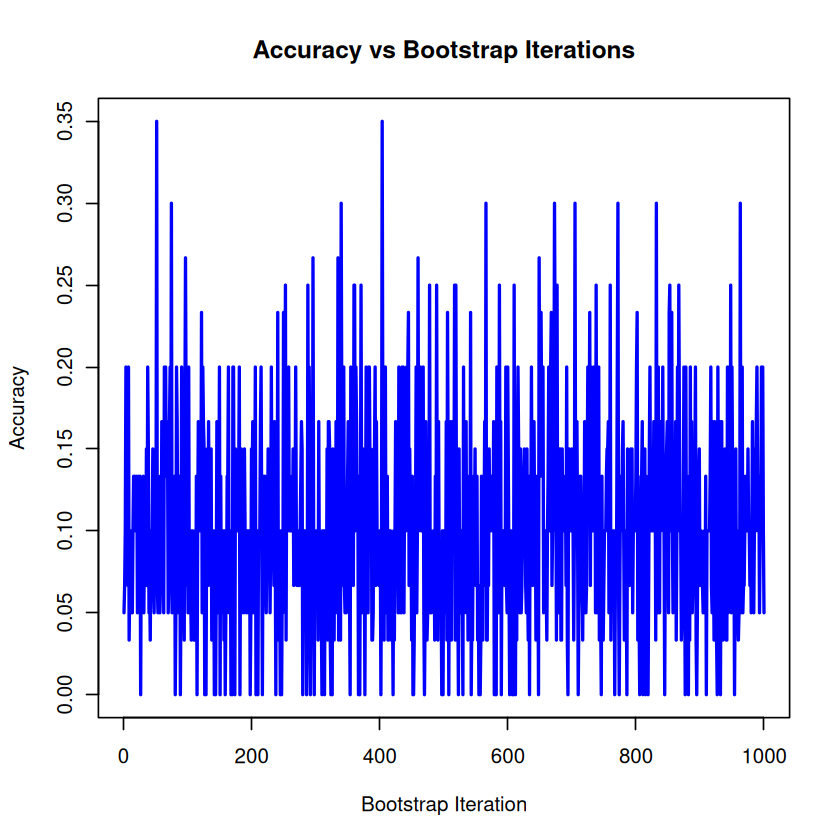

In [381]:
bootstrap_results_shuffled <- bootstrap_evaluation(df_synthetic, B = n_B, shuffleIndividuals = TRUE)

accuracy_ci_shuffled <- quantile(bootstrap_results_shuffled$metrics$Accuracy, c(0.025, 0.975))
cat("\n95% Confidence Interval for Accuracy with Shuffled Labels: ", accuracy_ci_shuffled, "\n")


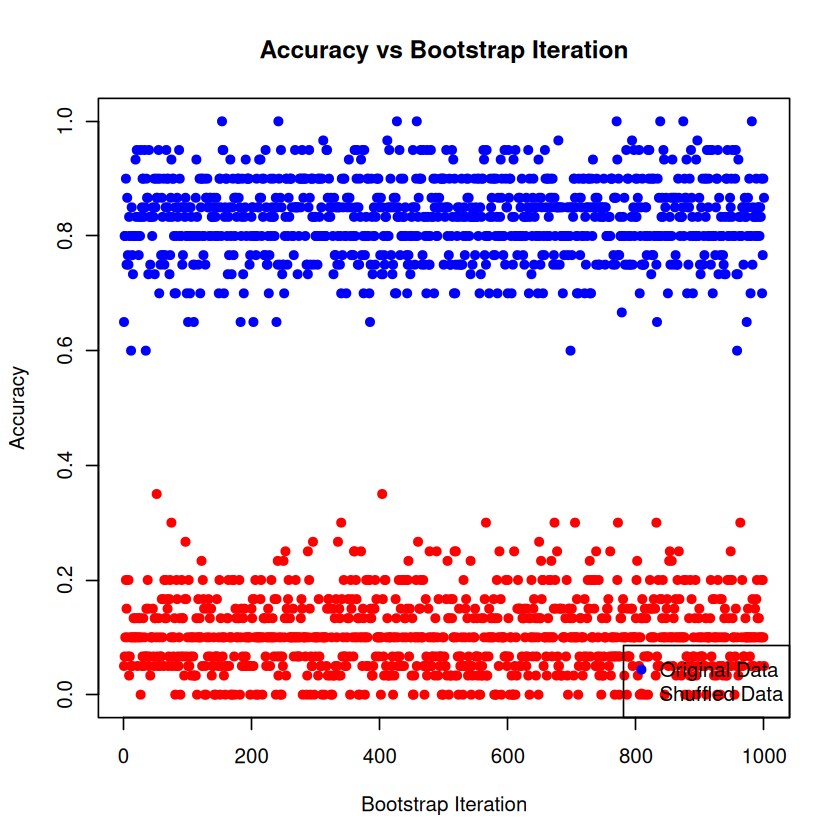

In [382]:
plot(1:n_B, bootstrap_results$metrics$Accuracy, type = "p", col = "blue", pch = 16,
     xlab = "Bootstrap Iteration", ylab = "Accuracy",
     main = "Accuracy vs Bootstrap Iteration",
     ylim = range(c(bootstrap_results$metrics$Accuracy, bootstrap_results_shuffled$metrics$Accuracy)))
points(1:n_B, bootstrap_results_shuffled$metrics$Accuracy, col = "red", pch = 16)

legend("bottomright", legend = c("Original Data", "Shuffled Data"),
       col = c("blue", "red"), pch = 16)


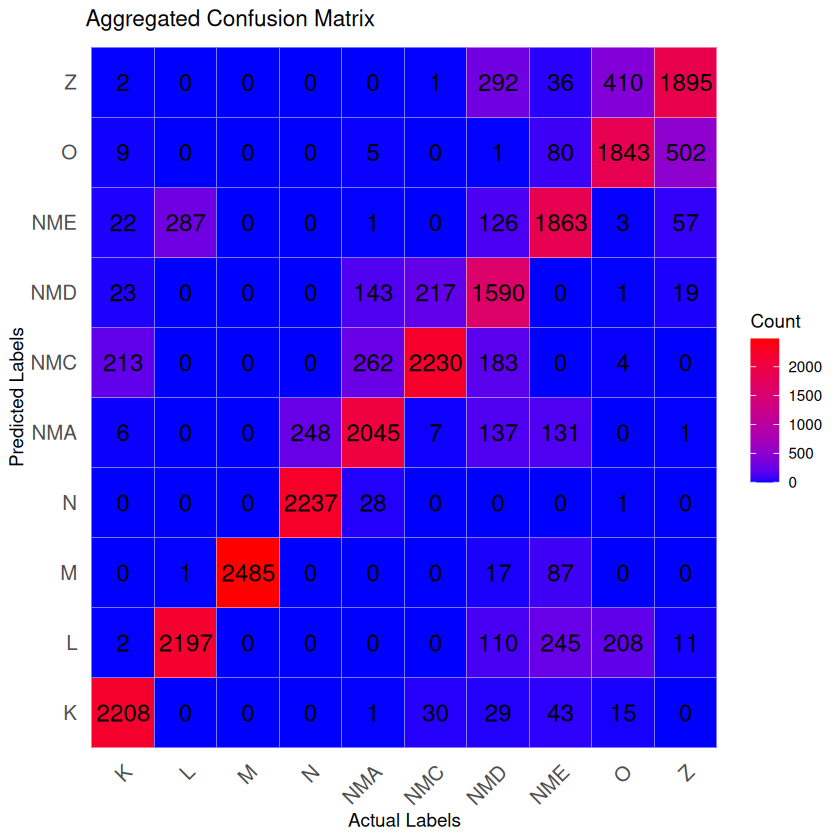

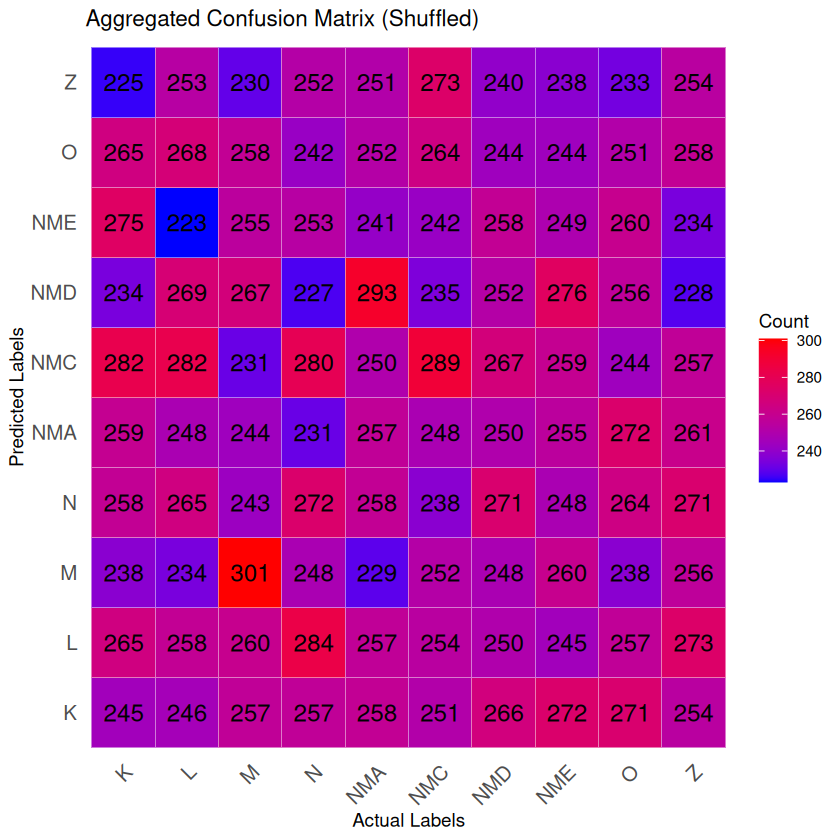

In [385]:
combine_confusion_matrices <- function(cm_list) {
  combined_table <- Reduce(function(x, y) x + y, lapply(cm_list, function(cm) cm$table))
  combined_cm <- cm_list[[1]] # Use the structure of the first confusion matrix
  combined_cm$table <- combined_table
  return(combined_cm)
}

combined_cm <- combine_confusion_matrices(bootstrap_results$confusion_matrices)

plot_cm(combined_cm, cm_title = "Aggregated Confusion Matrix", cm_stats = FALSE)

combined_cm_shuffled <- combine_confusion_matrices(bootstrap_results_shuffled$confusion_matrices)

plot_cm(combined_cm_shuffled, cm_title = "Aggregated Confusion Matrix (Shuffled)", cm_stats = FALSE)



Overall Statistics:
Accuracy:  0.65 
95% CI: ( 0.4078115 , 0.8460908 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  3.923225e-09 
Kappa:  0.6111111 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K           1.0      1.0000         1.0000         1.0000    1.0000
Class: L           1.0      0.9444         0.6667         1.0000    0.6667
Class: M           1.0      1.0000         1.0000         1.0000    1.0000
Class: N           0.5      1.0000         1.0000         0.9474    1.0000
Class: NMA         0.5      0.8333         0.2500         0.9375    0.2500
Class: NMC         1.0      0.9444         0.6667         1.0000    0.6667
Class: NMD         1.0      1.0000         1.0000         1.0000    1.0000
Class: NME         0.0      1.0000            NaN         0.9000        NA
Class: O           0.0      0.9444         0.0000         0.8947    0.0000
Class: Z           0.5      0.9444         0.5000         0.9444    0.5000

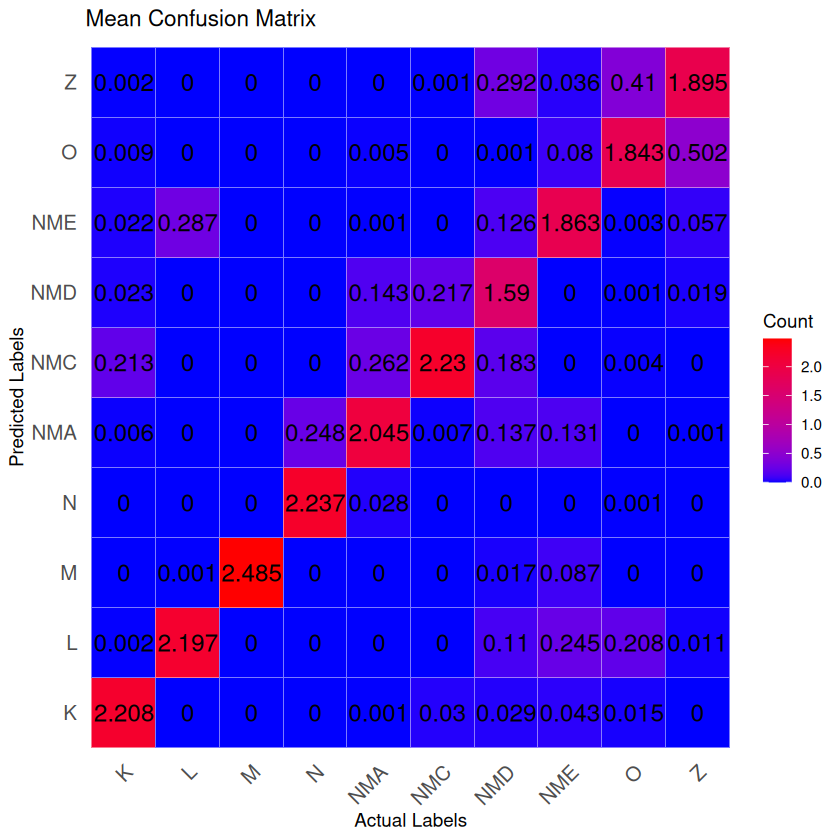

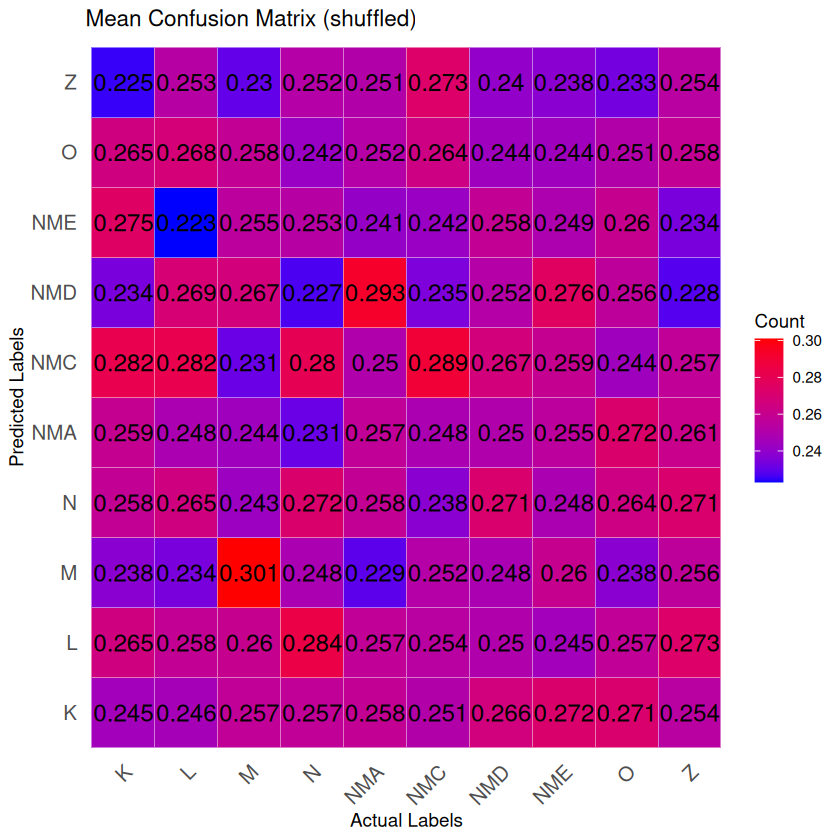

In [384]:
mean_confusion_matrix <- function(cm_list) {
  combined_table <- Reduce(`+`, lapply(cm_list, function(cm) cm$table))
  
  mean_table <- combined_table / length(cm_list)
  
  mean_cm <- cm_list[[1]]
  mean_cm$table <- mean_table
  
  return(mean_cm)
}

mean_cm <- mean_confusion_matrix(bootstrap_results$confusion_matrices)

plot_cm(mean_cm, cm_title = "Mean Confusion Matrix")

mean_cm_shuffled <- mean_confusion_matrix(bootstrap_results_shuffled$confusion_matrices)

plot_cm(mean_cm_shuffled, cm_title = "Mean Confusion Matrix (shuffled)")


Evaluating for n_PC = 2 
Evaluating for n_PC = 3 
Evaluating for n_PC = 4 
Evaluating for n_PC = 5 
Evaluating for n_PC = 6 
Evaluating for n_PC = 7 
Evaluating for n_PC = 8 
Evaluating for n_PC = 9 
Evaluating for n_PC = 10 
Evaluating for n_PC = 11 
Evaluating for n_PC = 12 
Evaluating for n_PC = 13 
Evaluating for n_PC = 14 
Evaluating for n_PC = 15 
Evaluating for n_PC = 16 
Evaluating for n_PC = 17 
Evaluating for n_PC = 18 
Evaluating for n_PC = 19 
Evaluating for n_PC = 20 
Evaluating for n_PC = 21 
Evaluating for n_PC = 22 
Evaluating for n_PC = 23 
Evaluating for n_PC = 24 
Evaluating for n_PC = 25 
Evaluating for n_PC = 26 
Evaluating for n_PC = 27 
Evaluating for n_PC = 28 
Evaluating for n_PC = 29 
Evaluating for n_PC = 30 
Evaluating for n_PC = 31 
Evaluating for n_PC = 32 
Evaluating for n_PC = 33 
Evaluating for n_PC = 34 
Evaluating for n_PC = 35 
Evaluating for n_PC = 36 
Evaluating for n_PC = 37 
Evaluating for n_PC = 38 
Evaluating for n_PC = 39 
Evaluating for n_PC 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


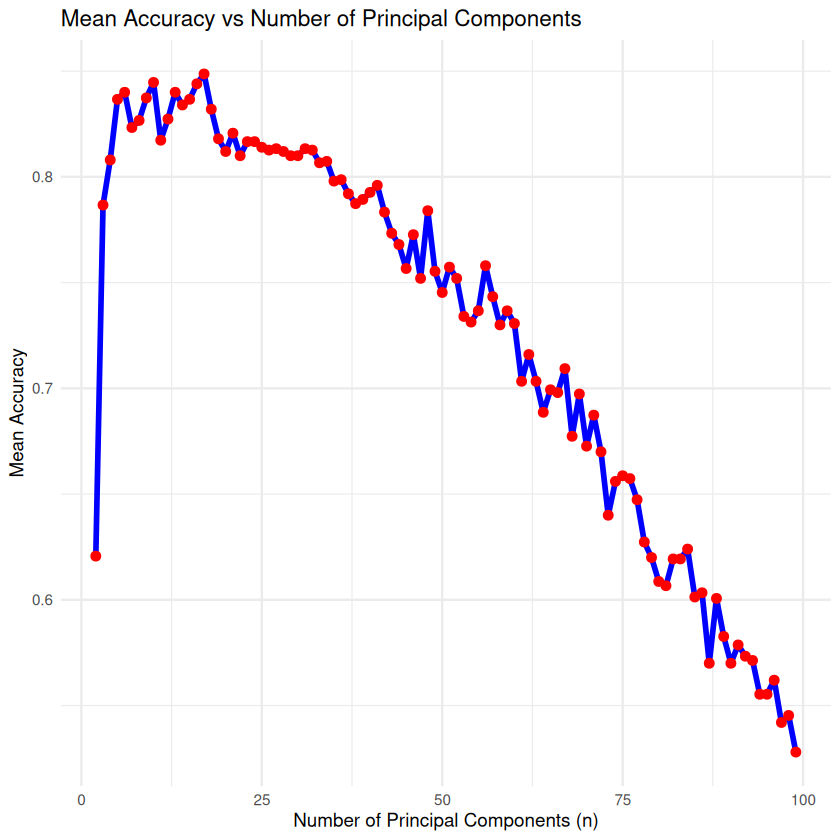

In [336]:
df_synthetic <- readRDS('./data/Propagation_experiments/df_pca_synthetic.rds')
df_synthetic <- df_synthetic[sample(nrow(df_synthetic)), ]
df_synthetic$Individual <- factor(df_synthetic$Individual)

n_min <- 2
n_max <- 99
n_iterations <- 50

# Store mean accuracies
mean_accuracies <- numeric(n_max - n_min + 1)

for (n in n_min:n_max) {
  cat("Evaluating for n_PC =", n, "\n")
  accuracies <- numeric(n_iterations)

  for (i in 1:n_iterations) {
    # Ensure valid training set with all classes
    valid_split <- FALSE
    while (!valid_split) {
      train_indices <- createDataPartition(df_synthetic$Individual, p = 0.7, list = FALSE)

      train_data <- df_synthetic[train_indices, ]
      test_data <- df_synthetic[-train_indices, ]

      # Balance the training set (force all classes to be present)
      if (!all(levels(df_synthetic$Individual) %in% train_data$Individual)) next
      train_data <- downSample(x = train_data[, 1:n], y = train_data$Individual)
      colnames(train_data)[n + 1] <- "Individual"

      # Check again for class presence
      if (all(levels(df_synthetic$Individual) %in% train_data$Individual)) {
        valid_split <- TRUE
      }
    }

    # Select n principal components
    X_train <- train_data[, 1:n]
    y_train <- train_data$Individual

    X_test <- test_data[, 1:n]
    y_test <- test_data$Individual

    # Train the model (ensure tuneGrid is a data frame)
    final_model <- train(
      x = X_train,
      y = y_train,
      method = "rf",
      tuneGrid = data.frame(mtry = 2),
      preProcess = c("center", "scale"),
      trControl = trainControl(method = "none")
    )

    # Predict and evaluate on the test set
    y_pred_test <- predict(final_model, newdata = X_test)
    cm_test <- confusionMatrix(y_pred_test, y_test)

    accuracies[i] <- cm_test$overall["Accuracy"]
  }

  # Store the mean accuracy for the current n
  mean_accuracies[n - n_min + 1] <- mean(accuracies)
}

# Create a DataFrame for the plot
accuracy_df <- data.frame(
  n = n_min:n_max,
  accuracy = mean_accuracies
)

# Plot mean accuracy vs number of principal components
ggplot(accuracy_df, aes(x = n, y = accuracy)) +
  geom_line(color = "blue", size = 1.2) +
  geom_point(color = "red", size = 2) +
  labs(title = "Mean Accuracy vs Number of Principal Components",
       x = "Number of Principal Components (n)",
       y = "Mean Accuracy") +
  theme_minimal()


# Calculate feature importance from random forest

### On propagation data

In [101]:
df <- readRDS(file = "./data/Propagation_experiments/df_voc_pca.rds")


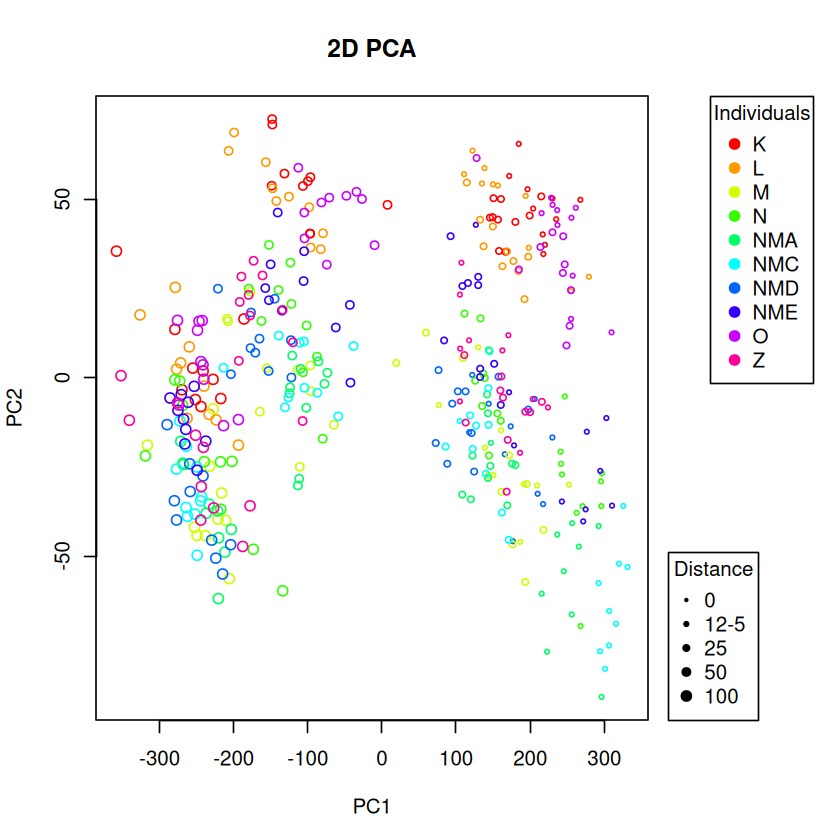

In [102]:
plot_df_pca_2D(df, colorType = "Individual")



  K   L   M   N NMA NMC NMD NME   O   Z 
 40  40  40  40  40  40  40  40  40  40 
Training size:  70 
Testing size:  30 



Overall Statistics:
Accuracy:  0.8380952 
95% CI: ( 0.8069657 , 0.8660137 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  0 
Kappa:  0.8201058 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K        1.0000      0.9894         0.9130         1.0000    0.9130
Class: L        0.9524      0.9912         0.9231         0.9947    0.9231
Class: M        1.0000      1.0000         1.0000         1.0000    1.0000
Class: N        0.8413      0.9700         0.7571         0.9821    0.7571
Class: NMA      0.5873      0.9506         0.5692         0.9540    0.5692
Class: NMC      0.7143      0.9665         0.7031         0.9682    0.7031
Class: NMD      0.6349      0.9700         0.7018         0.9599    0.7018
Class: NME      0.7937      1.0000         1.0000         0.9776    1.0000
Class: O        0.8730      0.9947         0.9483         0.9860    0.9483
Class: Z        0.9841      0.9877         0.8986         0.9982    0.8986
     

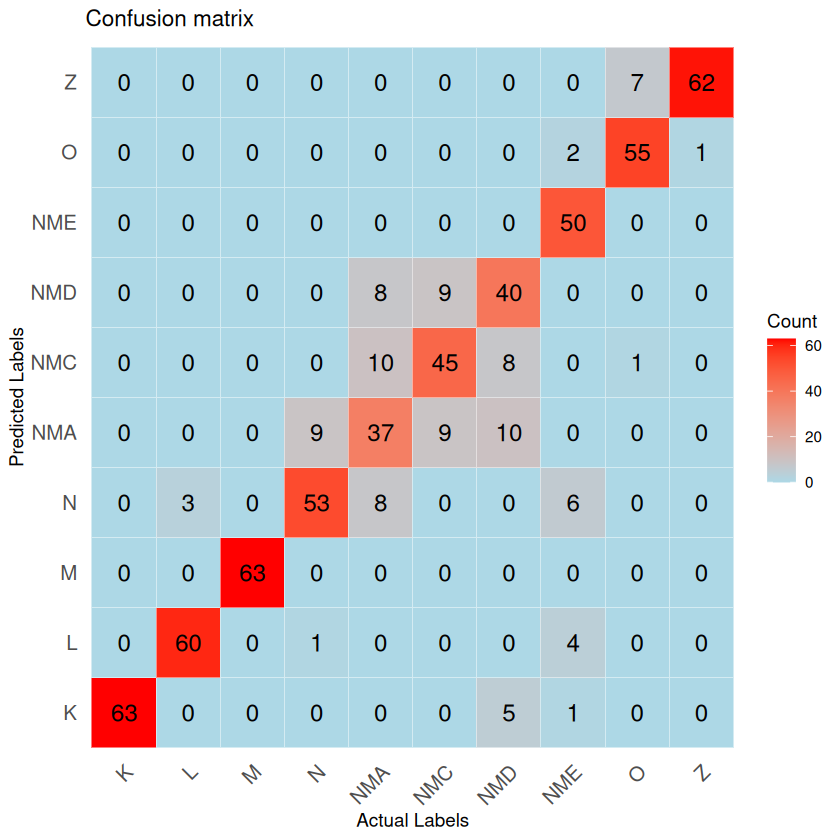

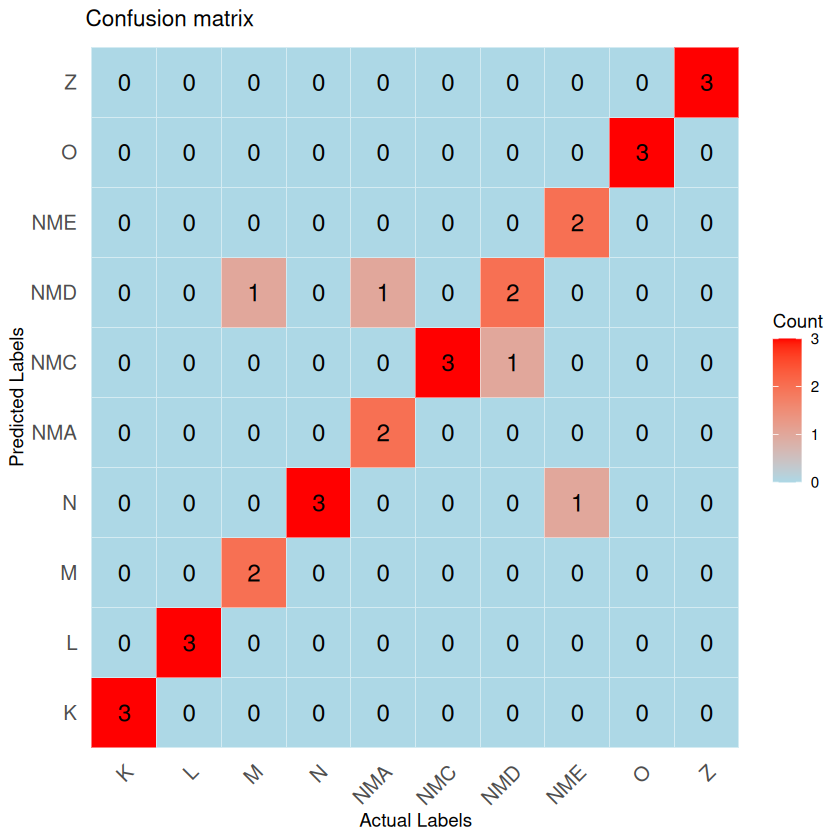

In [103]:

set.seed(42)  

df$Individual <- factor(df$Individual)

print(table(df$Individual))

df_filtered <- df %>% filter(Distance %in% c("12-5"))

train_indices <- createDataPartition(df_filtered$Individual, p = 0.7, list = FALSE)

train_data <- df_filtered[train_indices, ]
test_data <- df_filtered[-train_indices, ]

cat("Training size: ", nrow(train_data), "\n")
cat("Testing size: ", nrow(test_data), "\n")

n <- 20

X_train <- train_data[, 0:n]
y_train <- train_data$Individual

X_test <- test_data[, 0:n]
y_test <- test_data$Individual

model <- cross_validation(X_train, X_test, y_train, y_test, "rf")
cm <- confusionMatrix(model$pred$pred, model$pred$obs)

plot_cm(cm)

# Display confusion matrix for test set results
y_pred_test <- predict(model, newdata = X_test)

cm_test <- confusionMatrix(y_pred_test, y_test)

plot_cm(cm_test)



## Training and Testing on DIFFERENT Distances


  K   L   M   N NMA NMC NMD NME   O   Z 
 10  10  10  10  10  10  10  10  10  10 


Overall Statistics:
Accuracy:  0.9022222 
95% CI: ( 0.8809248 , 0.9208404 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  0 
Kappa:  0.891358 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K        1.0000      0.9988         0.9890         1.0000    0.9890
Class: L        1.0000      0.9938         0.9474         1.0000    0.9474
Class: M        0.9778      0.9988         0.9888         0.9975    0.9888
Class: N        0.9000      0.9889         0.9000         0.9889    0.9000
Class: NMA      0.8333      0.9654         0.7282         0.9812    0.7282
Class: NMC      0.7556      0.9778         0.7907         0.9730    0.7907
Class: NMD      0.7889      0.9704         0.7474         0.9764    0.7474
Class: NME      0.7889      1.0000         1.0000         0.9771    1.0000
Class: O        0.9889      0.9988         0.9889         0.9988    0.9889
Class: Z        0.9889      0.9988         0.9889         0.9988    0.9889
      

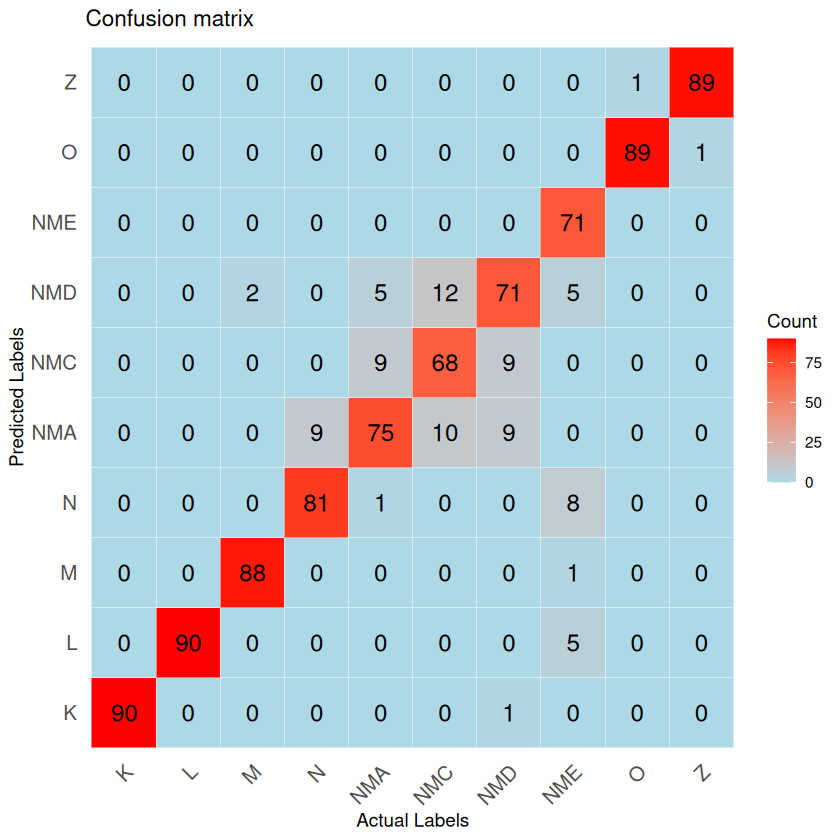

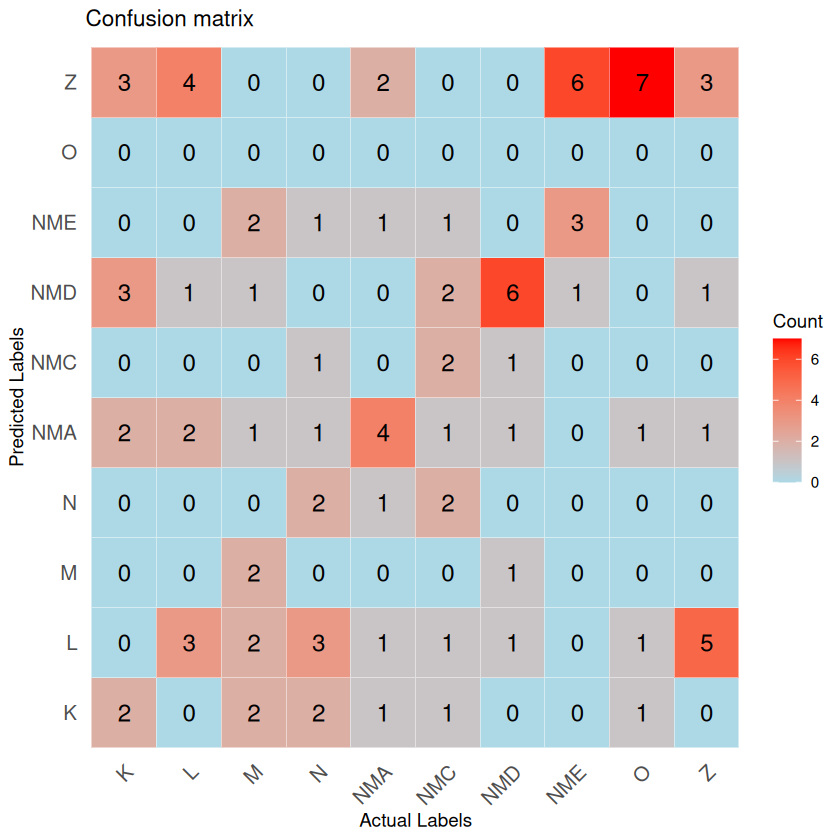

In [106]:
set.seed(42)

df <- df[sample(nrow(df)), ] # Shuffling the dataset

df$Individual <- factor(df$Individual)

training_distance = "12-5"
testing_distance = "100"

train_data <- df[df$Distance == training_distance, ]  
test_data <- df[df$Distance == testing_distance, ]    

table(test_data$Individual)

n_comp <- 29

X_train <- train_data[, 0:n_comp]
y_train <- train_data$Individual

X_test <- test_data[, 0:n_comp]
y_test <- test_data$Individual


model <- cross_validation(X_train, X_test, y_train, y_test, "rf", n_folds = 5)
cm <- confusionMatrix(model$pred$pred, model$pred$obs)

plot_cm(cm, cm_stats = TRUE)

# Display confusion matrix for test set results
y_pred_test <- predict(model, newdata = X_test)

cm_test <- confusionMatrix(y_pred_test, y_test)

plot_cm(cm_test, cm_stats = TRUE)


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin





Overall Statistics:
Accuracy:  0.85 
95% CI: ( 0.7646925 , 0.9135456 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  5.318938e-69 
Kappa:  0.8333333 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K           1.0      1.0000         1.0000         1.0000    1.0000
Class: L           1.0      1.0000         1.0000         1.0000    1.0000
Class: M           0.9      1.0000         1.0000         0.9890    1.0000
Class: N           0.9      1.0000         1.0000         0.9890    1.0000
Class: NMA         0.8      0.9667         0.7273         0.9775    0.7273
Class: NMC         0.2      1.0000         1.0000         0.9184    1.0000
Class: NMD         0.9      0.8889         0.4737         0.9877    0.4737
Class: NME         0.8      1.0000         1.0000         0.9783    1.0000
Class: O           1.0      1.0000         1.0000         1.0000    1.0000
Class: Z           1.0      0.9778         0.8333         1.0000    0.8333

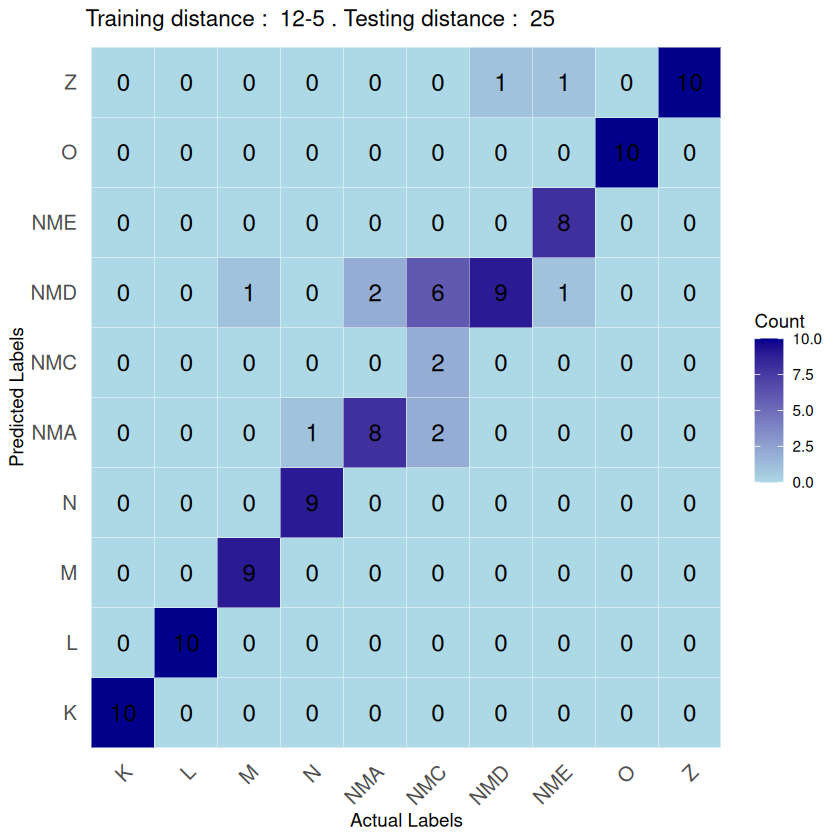

In [28]:
set.seed(42)

library(randomForest)

rf_model <- randomForest(x = X_train, y = y_train, ntree = 250, mtry = sqrt(n_comp), maxnodes = 50)

y_pred_rf <- predict(rf_model, newdata = X_test)

confusion_matrix_rf <- confusionMatrix(y_pred_rf, y_test)

plot_cm(confusion_matrix_rf, paste("Training distance : ",training_distance, ". Testing distance : ", testing_distance))

misclassified_indices <- which(y_pred != y_test)

misclassified_info <- data.frame(
  Predicted_Label = y_pred[misclassified_indices]
)

print("Misclassified Examples (True vs Predicted Labels):")
print(misclassified_info)


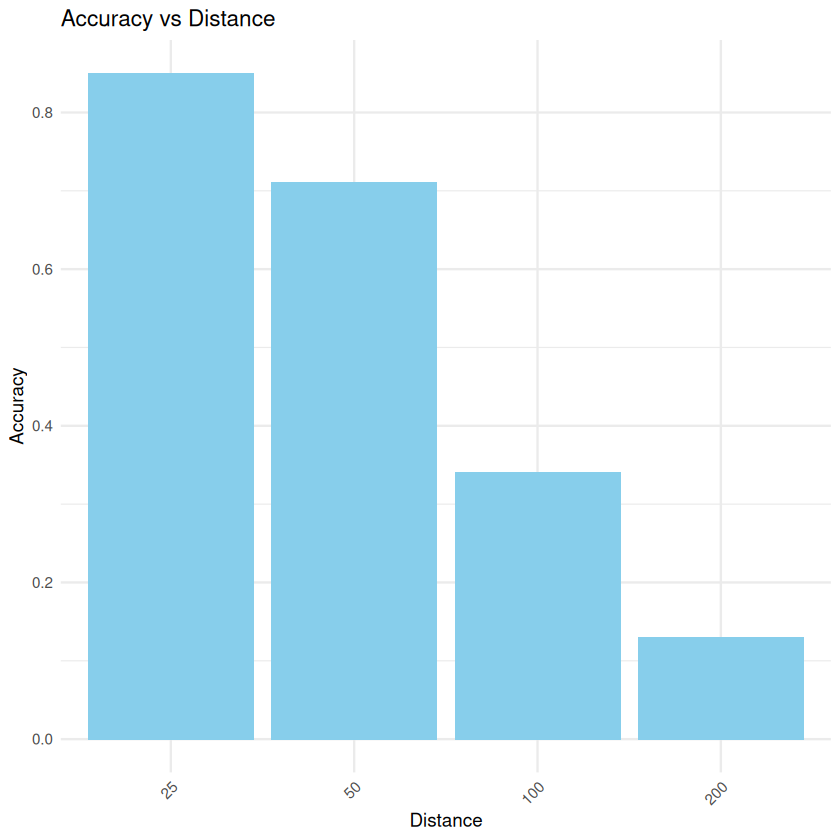

In [29]:
distances_to_test <- c("25","50", "100", "200")

accuracy_results <- data.frame(Distance = character(), Accuracy = numeric())

for (distance in distances_to_test) {
  train_subset <- df[df$Distance == distance & df$Type == "Signal", ]
  
  X_train_subset <- train_subset[, 1:n_comp]
  y_train_subset <- train_subset$Individual
  
  y_pred_subset <- predict(rf_model, newdata = X_train_subset)
  
  confusion_matrix_subset <- confusionMatrix(y_pred_subset, y_train_subset)
  accuracy <- confusion_matrix_subset$overall['Accuracy']
  
  accuracy_results <- rbind(accuracy_results, data.frame(Distance = distance, Accuracy = accuracy))
}

accuracy_results$Distance <- factor(accuracy_results$Distance, levels = distances_to_test)

library(ggplot2)

ggplot(accuracy_results, aes(x = Distance, y = Accuracy)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  theme_minimal() +
  labs(title = "Accuracy vs Distance", x = "Distance", y = "Accuracy") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



Attaching package: ‘plotrix’


The following object is masked from ‘package:fields’:

    color.scale


The following object is masked from ‘package:seewave’:

    rescale




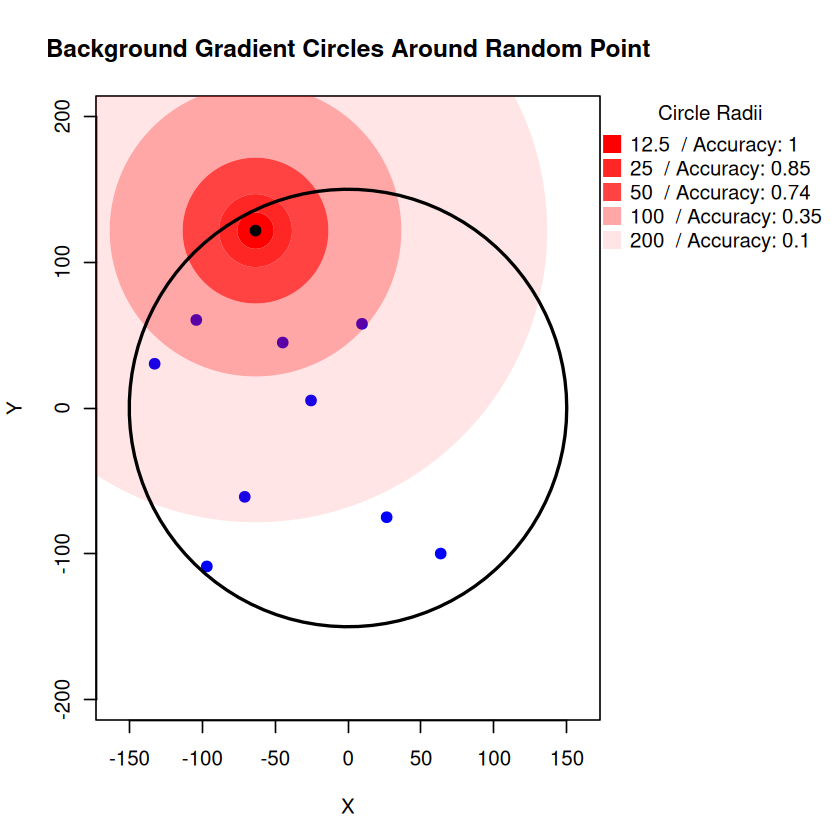

In [30]:
radius <- 150
num_points <- 10

angles <- runif(num_points, 0, 2 * pi)
radii <- sqrt(runif(num_points, 0, radius^2))

x_coords <- radii * cos(angles)
y_coords <- radii * sin(angles)

random_index <- sample(1:num_points, 1)
random_point <- c(x_coords[random_index], y_coords[random_index])

colors_gradient <- colorRampPalette(c("blue", "green", "yellow", "red"))(10)

par(mar = c(5, 4, 4, 10))  # (bottom, left, top, right)

plot(x_coords, y_coords, pch = 19, col = "blue", xlab = "X", ylab = "Y", 
     main = "Background Gradient Circles Around Random Point", 
     xlim = c(-radius-10, radius+10), ylim = c(-radius-10, radius+10), 
     asp = 1)

distances <- c(12.5, 25, 50, 100, 200)
accuracies <- c(1, 0.85, 0.74, 0.35, 0.1)
colors <- c(
  rgb(1, 0, 0, alpha = 1),  
  rgb(1, 0, 0, alpha = 0.85),  
  rgb(1, 0, 0, alpha = 0.74),  
  rgb(1, 0, 0, alpha = 0.35),
  rgb(1, 0, 0, alpha = 0.1)  
)

library(plotrix)

draw_donut <- function(center_x, center_y, outer_radius, inner_radius, color) {
  theta <- seq(0, 2 * pi, length.out = 300)
  
  outer_x <- center_x + outer_radius * cos(theta)
  outer_y <- center_y + outer_radius * sin(theta)
  
  inner_x <- rev(center_x + inner_radius * cos(theta))
  inner_y <- rev(center_y + inner_radius * sin(theta))
  
  polygon(c(outer_x, inner_x), c(outer_y, inner_y), border = NA, col = color)
}

for (i in length(distances):1) {
  outer_radius <- distances[i]
  inner_radius <- if (i == 1) 0 else distances[i - 1]
  fill_color <- colors[i]
  
  draw_donut(random_point[1], random_point[2], outer_radius, inner_radius, fill_color)
}

theta <- seq(0, 2 * pi, length.out = 100)
x_boundary <- radius * cos(theta)
y_boundary <- radius * sin(theta)
lines(x_boundary, y_boundary, col = "black", lwd = 2)

points(random_point[1], random_point[2], pch = 19, col = "black", cex = 1)

legend("topright", legend = paste(distances," / Accuracy:", accuracies), 
       col = colors, pch = 15, pt.cex = 2, bty = "n", 
       title = "Circle Radii", xpd = TRUE, inset = c(-0.45, 0))


# Dataframe combining propagation signals + synthetic signals

In [89]:
df_signals <- readRDS("./data/Propagation_experiments/df_signals_pca.rds")
summary(df_signals)


      PC1               PC2               PC3                PC4         
 Min.   :-368.00   Min.   :-204.97   Min.   :-109.872   Min.   :-45.856  
 1st Qu.:-178.97   1st Qu.:   7.93   1st Qu.:  -5.118   1st Qu.:-11.529  
 Median :  95.17   Median :  23.63   Median :   1.293   Median : -1.588  
 Mean   :   0.00   Mean   :   0.00   Mean   :   0.000   Mean   :  0.000  
 3rd Qu.: 130.83   3rd Qu.:  71.33   3rd Qu.:   7.128   3rd Qu.: 11.930  
 Max.   : 292.69   Max.   : 116.43   Max.   :  57.376   Max.   : 65.550  
      PC5                PC6                PC7                PC8         
 Min.   :-34.5498   Min.   :-43.3077   Min.   :-39.9992   Min.   :-47.422  
 1st Qu.:-12.0648   1st Qu.: -8.1387   1st Qu.: -6.2409   1st Qu.: -6.604  
 Median :  0.6851   Median : -0.5474   Median : -0.1916   Median : -1.332  
 Mean   :  0.0000   Mean   :  0.0000   Mean   :  0.0000   Mean   :  0.000  
 3rd Qu.: 12.3830   3rd Qu.:  7.6488   3rd Qu.:  5.7275   3rd Qu.:  6.254  
 Max.   : 57.4750   Max.  

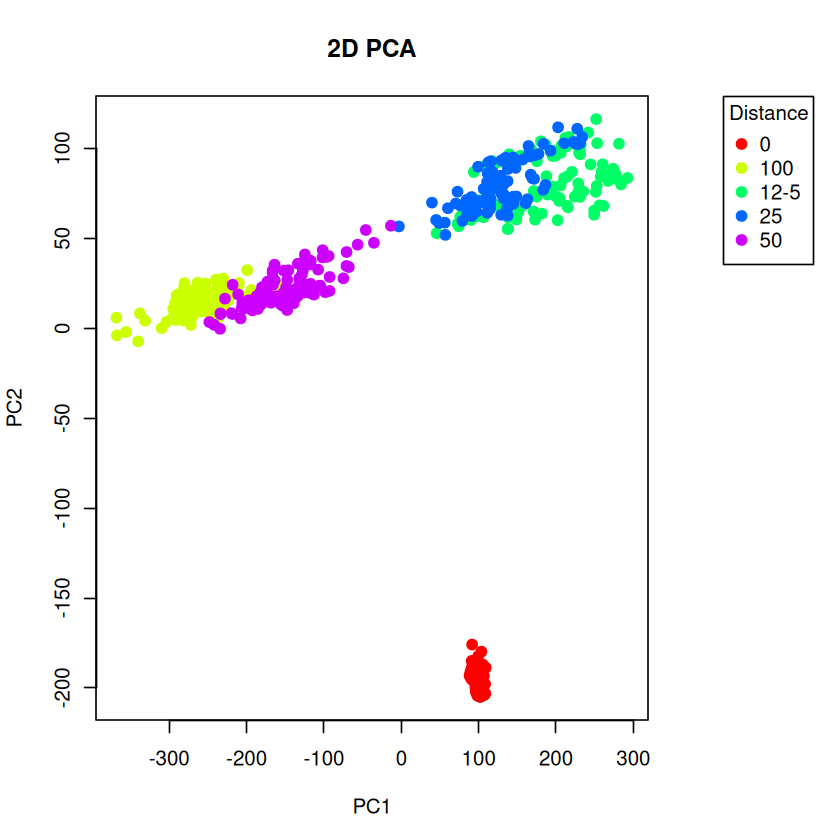

In [90]:
plot_df_pca_2D(df_signals, colorType = "Distance", distance = FALSE)




  K   L   M   N NMA NMC NMD NME   O   Z 
 10  10  10  10  10  10  10  10  10  10 

Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid 


Overall Statistics:
Accuracy:  0.7966667 
95% CI: ( 0.7688643 , 0.8225113 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  0 
Kappa:  0.7740741 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K        0.9556      0.9864         0.8866         0.9950    0.8866
Class: L        0.9000      0.9753         0.8020         0.9887    0.8020
Class: M        1.0000      0.9988         0.9890         1.0000    0.9890
Class: N        0.9000      0.9901         0.9101         0.9889    0.9101
Class: NMA      0.7111      0.9642         0.6882         0.9678    0.6882
Class: NMC      0.8444      0.9741         0.7835         0.9826    0.7835
Class: NMD      0.7111      0.9667         0.7033         0.9679    0.7033
Class: NME      0.5000      0.9840         0.7759         0.9466    0.7759
Class: O        0.7444      0.9741         0.7614         0.9717    0.7614
Class: Z        0.7000      0.9605         0.6632         0.9665    0.6632
     

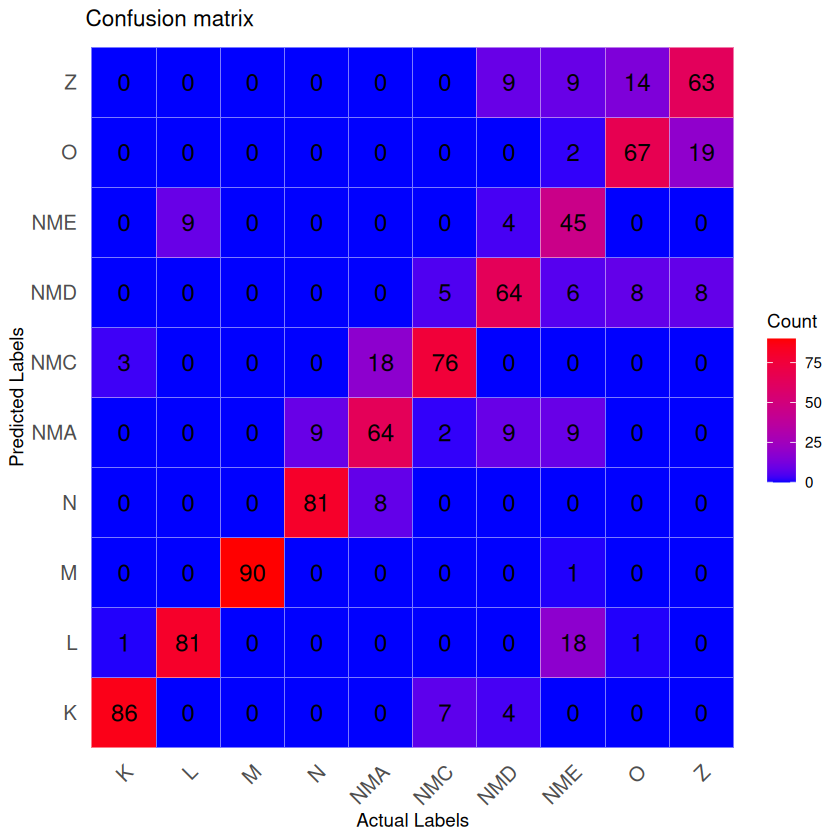

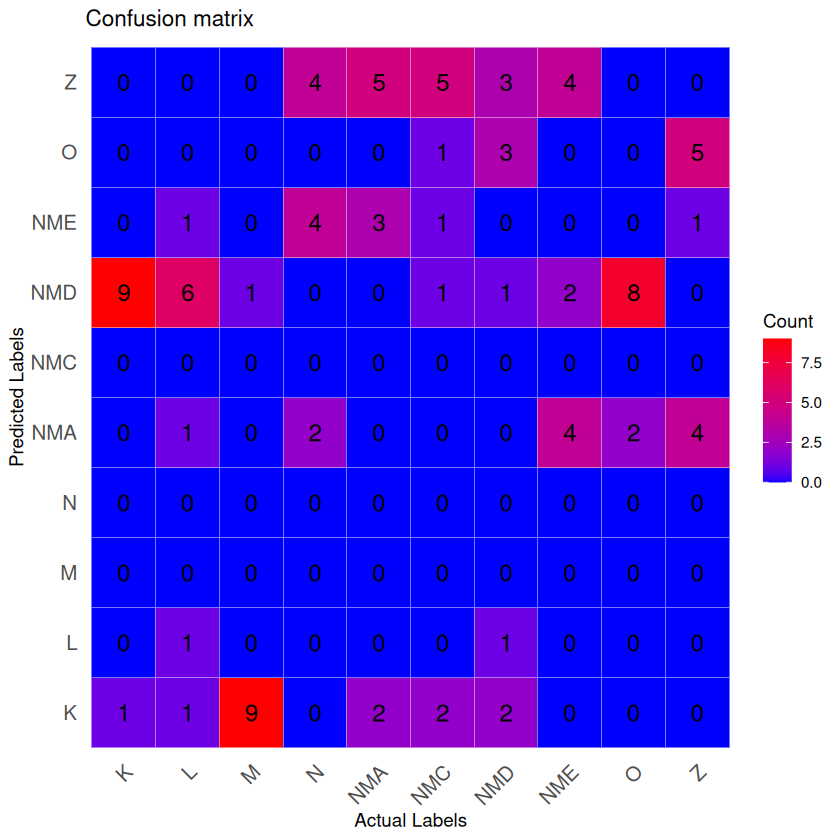

In [ ]:
set.seed(42)

df_signals <- df_signals[sample(nrow(df_signals)), ] # Shuffling the dataset

df_signals$Individual <- factor(df_signals$Individual)

training_distance = "0"
testing_distance = "12-5"

train_data <- df_signals[df_signals$Distance == training_distance, ]  
test_data <- df_signals[df_signals$Distance == testing_distance, ]    

table(test_data$Individual)

n_comp <- 25 # n_comp + 1

X_train <- train_data[, 1:n_comp]
y_train <- train_data$Individual

X_test <- test_data[, 1:n_comp]
y_test <- test_data$Individual


model <- cross_validation(X_train, X_test, y_train, y_test, "rf", n_folds = 5)
cm <- confusionMatrix(model$pred$pred, model$pred$obs)

plot_cm(cm, cm_stats = TRUE)

# Display confusion matrix for test set results
y_pred_test <- predict(model, newdata = X_test)

cm_test <- confusionMatrix(y_pred_test, y_test)

plot_cm(cm_test, cm_stats = TRUE)



  K   L   M   N NMA NMC NMD NME   O   Z 
 60  60  60  60  60  60  60  60  60  60 
Training size:  70 
Testing size:  30 

Overall Statistics:
Accuracy:  0.7793651 
95% CI: ( 0.7449199 , 0.8111671 )
No Information Rate:  0.1 
P-Value [Acc > NIR]:  0 
Kappa:  0.7548501 

Statistics by Class:
           Sensitivity Specificity Pos Pred Value Neg Pred Value Precision
Class: K        1.0000      0.9806         0.8514         1.0000    0.8514
Class: L        0.9841      0.9824         0.8611         0.9982    0.8611
Class: M        0.9841      0.9877         0.8986         0.9982    0.8986
Class: N        0.8571      1.0000         1.0000         0.9844    1.0000
Class: NMA      0.8254      0.9489         0.6420         0.9800    0.6420
Class: NMC      0.7143      0.9647         0.6923         0.9681    0.6923
Class: NMD      0.7143      0.9841         0.8333         0.9688    0.8333
Class: NME      0.3810      0.9806         0.6857         0.9345    0.6857
Class: O        0.7460      0.970

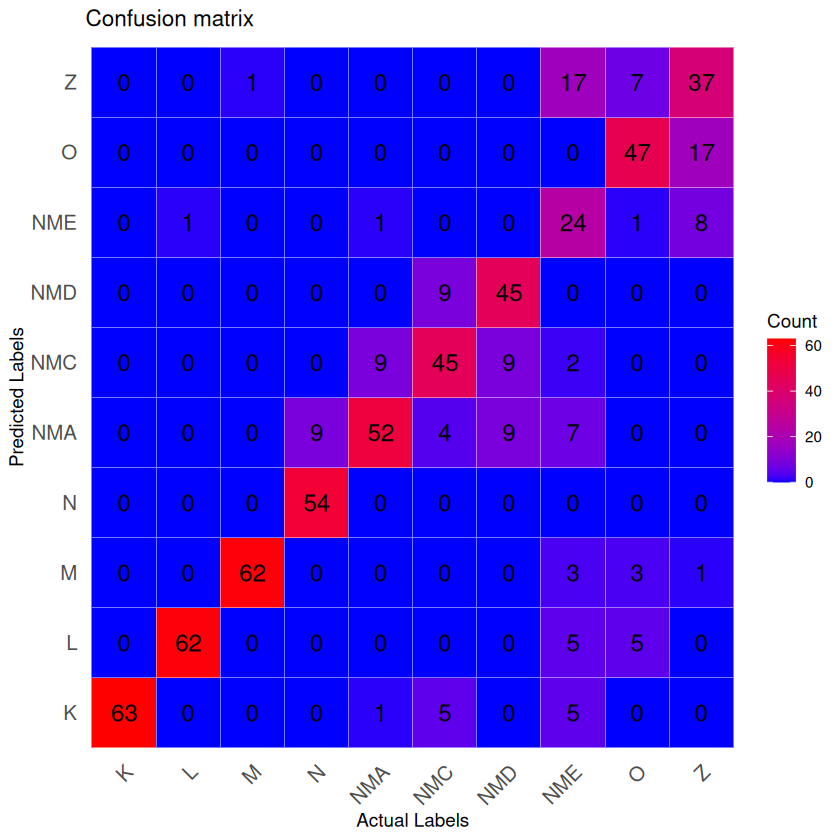

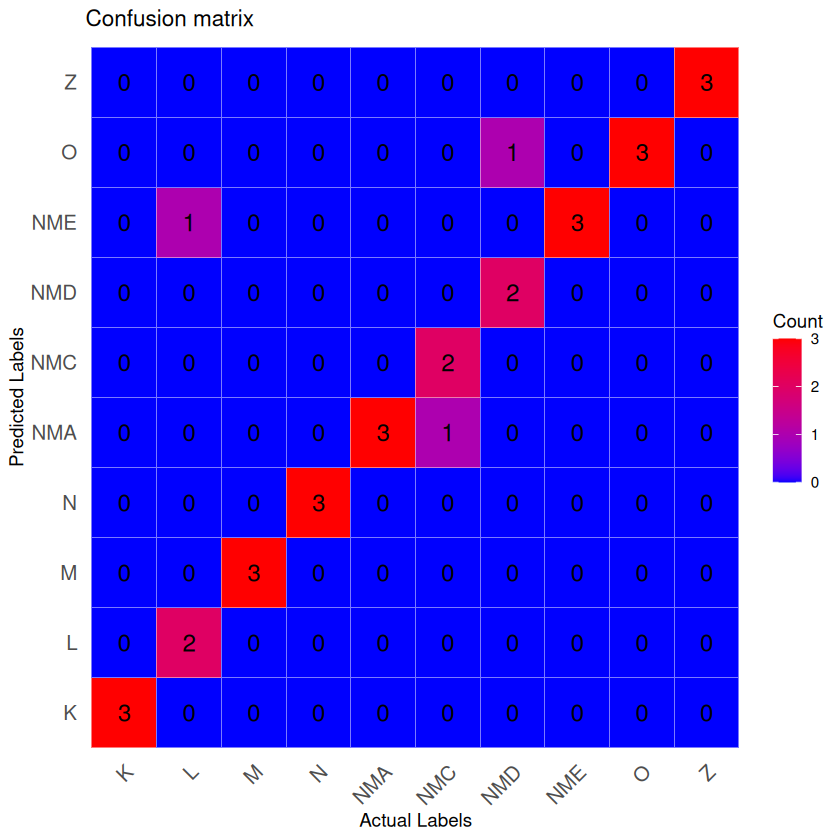

In [368]:
set.seed(42)  

df_signals <- df_signals[sample(nrow(df_signals)), ] # Shuffling the dataset

df_signals$Individual <- factor(df_signals$Individual)

print(table(df_signals$Individual))

df_signals_filtered <- df_signals %>% filter(Distance %in% c("0"))

train_indices <- createDataPartition(df_signals_filtered$Individual, p = 0.7, list = FALSE)

train_data <- df_signals_filtered[train_indices, ]
test_data <- df_signals_filtered[-train_indices, ]

cat("Training size: ", nrow(train_data), "\n")
cat("Testing size: ", nrow(test_data), "\n")

n <- 30

X_train <- train_data[, 1:n]
y_train <- train_data$Individual

X_test <- test_data[, 1:n]
y_test <- test_data$Individual

model <- cross_validation(X_train, X_test, y_train, y_test, "rf")
cm <- confusionMatrix(model$pred$pred, model$pred$obs)

plot_cm(cm, cm_stats = TRUE)

# Display confusion matrix for test set results
y_pred_test <- predict(model, newdata = X_test)

cm_test <- confusionMatrix(y_pred_test, y_test)

plot_cm(cm_test, cm_stats = TRUE)

